# RAG Generation — Baseline vs Distilled Student

One question: **did distillation actually make the model better?**

Two generators go through the *same* retrieval pipeline, the *same* system prompt and the *same*
questions:

1. **Baseline** — `google/gemma-3-4b-it` in 4-bit, straight off the shelf.
2. **Distilled** — the same base model with the LoRA adapter from the distillation training
   notebook attached on top.

Only the generator changes. Database, retrieval code, prompt and questions are identical, so any
difference in the scores comes from the model and nothing else.

## What changed in this version

**The evaluation set is now 21 real KCC-style farmer questions** — messy capitalisation, trailing
dots, typos (`Damffing off`, `Leaf caurl`, `Merigold`), and a genuine three-way language mix of
English, Hindi and Hinglish. That is much closer to what the deployed system actually receives
than the tidy hand-written questions the previous version used.

**Four regex problems are fixed.** They were all silently corrupting the scores:

| # | problem | effect on the numbers |
|---|---|---|
| 1 | numbers compared as **strings** | context says `10.0`, answer says `10` → counted as invented |
| 2 | Devanagari digits (`१०`) never matched | every number in a Hindi answer counted as invented |
| 3 | `1,50,000` split into `1`, `50`, `000` | Indian-format figures counted as invented |
| 4 | only `[1]`-style citations recognised | `Sources: 1, 2` counted as *uncited*, and its digits counted as invented claims |

**Language detection is now three-way.** The old detector only returned `hi` or `en`, so every
Hinglish question ("Til varieties ke baare mein information chahiye") was labelled English and the
model was told to answer in English. Nine of the 21 questions in the new set are Hinglish or mixed.

**Queries are normalised before retrieval.** Trailing `......?`, shouted capitals and a small
typo dictionary are cleaned up for the *embedding* only — the model still sees the farmer's
original words.

**The RAGAS section is rewritten.** The previous version had fifteen overlapping cells that
re-filtered, re-merged and re-exported the same scores in four different ways, plus a stray
`df.head()` and a Colab-only download. It is now one input builder, one judge call, one results
table, one chart. Faithfulness is the metric; answer relevancy is behind a flag because it needs
an embeddings endpoint that the aipipe proxy does not always serve.

**Contexts are stored, not re-derived.** The old code re-ran the search to reconstruct what the
model had been shown. Now the exact context text is saved on the row at generation time, so the
regex grounding check and the RAGAS judge score against precisely the same text the model read.

## 1. Install packages

In [1]:
!pip install "langchain-community<0.4.2"

In [2]:
!pip install -q qdrant-client sentence-transformers transformers sentencepiece accelerate bitsandbytes peft --break-system-packages

## 2. Settings

Everything you might want to change is in this one cell.

`ADAPTER_DIR` is the one thing you must point at yourself: the folder containing
`adapter_config.json` (the `best_adapter` folder from the training notebook). If you only have
the zip bundle, set `ADAPTER_ZIP` and section 8 unzips it.

**`ANSWER_LEN_RANGE` is used in two places on purpose** — it is written into the prompt *and*
used by the `length_ok` check. In the previous notebook the prompt asked for 100-180 tokens while
the checker rewarded 60-110, so a model that followed instructions perfectly scored badly. One
constant now feeds both.

In [3]:
import os

# ---- what to run -----------------------------------------------------------------------------
RUN_EXAMPLES        = True    # three worked examples on both models before the full run
RUN_FULL_COMPARISON = True    # the whole evaluation set, both models
RUN_HEALTH          = True
RUN_RAGAS           = True    # section 16 onwards -- needs an AIPIPE_TOKEN
EXPORT_ARTIFACTS    = True

# ---- baseline generator (untouched, off the shelf) -------------------------------------------
BASELINE_MODEL_ID  = "google/gemma-3-4b-it"
BASELINE_LOAD_4BIT = True

# ---- distilled generator (base model + your trained adapter) ---------------------------------
ADAPTER_DIR = "/content/drive/MyDrive/best_adapter"
ADAPTER_ZIP = "/content/drive/MyDrive/final_model_bundle.zip"
# Left as None so the notebook reads it out of final_model_manifest.json. Only set it by hand if
# that file is missing.
DISTILLED_BASE_MODEL_ID = None

# ---- generation settings (identical for both models) -----------------------------------------
GEN_BASELINE = dict(
    temperature    = 0,      # greedy: the same question gives the same answer every run
    top_p          = 1,
    max_new_tokens = 220,
    ctx_top_k      = 5,
)

# One source of truth for answer length. Written into the prompt AND used by the length_ok
# check, so the two can never drift apart again.
ANSWER_LEN_RANGE = (90, 200)

# ---- retrieval ---------------------------------------------------------------------------------
NORMALISE_QUERIES = True   # clean trailing dots / shouting / typos before embedding (section 7)

# ---- where the database lives ------------------------------------------------------------------
ARTIFACT_DIR = "/content/drive/MyDrive/rag_production_bge_m3"

# ---- where results are saved --------------------------------------------------------------------
OUTPUT_DIR = "/content/drive/MyDrive/rag_comparison_baseline_vs_distilled"
FIG_DIR    = "/content/figures"
os.makedirs(FIG_DIR, exist_ok=True)

import json, re, time, math
print("settings loaded")
print(f"   answers should be {ANSWER_LEN_RANGE[0]}-{ANSWER_LEN_RANGE[1]} tokens "
      "(this same range goes into the prompt and into the scorer)")

settings loaded
   answers should be 90-200 tokens (this same range goes into the prompt and into the scorer)


## 3. Start the database server

Qdrant stores every chunk of text as a vector so it can be searched by meaning. Colab has no
Docker, so the plain binary is downloaded and run directly.

In [4]:
import os, subprocess, tarfile, time, requests

QDRANT_STORAGE = "/content/qdrant_serve_storage"
QDRANT_URL     = "http://localhost:6333"
QDRANT_BIN     = "/content/qdrant"
os.makedirs(QDRANT_STORAGE, exist_ok=True)

def qdrant_alive(url=QDRANT_URL, timeout=1):
    try:
        return requests.get(f"{url}/readyz", timeout=timeout).ok
    except Exception:
        return False

def binary_ok(path=QDRANT_BIN):
    """A downloaded file existing is not the same as it working -- actually run it."""
    if not os.path.exists(path):
        return False
    try:
        return subprocess.run([path, "--version"], capture_output=True, timeout=60).returncode == 0
    except Exception:
        return False

if qdrant_alive():
    print("Qdrant already running on :6333")
else:
    if not binary_ok():
        if os.path.exists(QDRANT_BIN):
            os.remove(QDRANT_BIN)
        rel = requests.get("https://api.github.com/repos/qdrant/qdrant/releases/latest",
                           timeout=30).json()
        asset = None
        for suffix in ("x86_64-unknown-linux-musl.tar.gz",   # no system library needed
                       "x86_64-unknown-linux-gnu.tar.gz"):   # needs a newer libc, last resort
            asset = next((a for a in rel["assets"] if a["name"].endswith(suffix)), None)
            if asset:
                break
        if asset is None:
            raise RuntimeError("no linux x86_64 asset in " + rel["tag_name"])
        print(f"downloading qdrant {rel['tag_name']} ({asset['name']}) ...")
        with open("/content/q.tar.gz", "wb") as f:
            f.write(requests.get(asset["browser_download_url"], timeout=600).content)
        with tarfile.open("/content/q.tar.gz") as t:
            try:
                t.extractall("/content", filter="data")
            except TypeError:
                t.extractall("/content")
        os.chmod(QDRANT_BIN, 0o755)
        if not binary_ok():
            raise RuntimeError("downloaded qdrant will not run here")

    env = dict(os.environ, QDRANT__STORAGE__STORAGE_PATH=QDRANT_STORAGE,
               QDRANT__TELEMETRY_DISABLED="true")
    qdrant_proc = subprocess.Popen([QDRANT_BIN], env=env, cwd="/content",
                                   stdout=open("/content/qdrant.log", "w"),
                                   stderr=subprocess.STDOUT)
    for _ in range(90):
        if qdrant_alive():
            break
        if qdrant_proc.poll() is not None:
            raise RuntimeError("qdrant exited early -- /content/qdrant.log:\n"
                               + open("/content/qdrant.log").read()[-1500:])
        time.sleep(1)
    else:
        raise RuntimeError("qdrant not ready in 90s -- see /content/qdrant.log")
    print("Qdrant server ready on :6333")

Qdrant server ready on :6333


## 4. Load the database

Uploads the saved snapshot (all chunks plus their vectors) into the running server. Skipped if
the collection is already there.

In [5]:
import json, os, time, requests

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print(f"(not on Colab / Drive already available: {type(e).__name__})")

assert os.path.isdir(ARTIFACT_DIR), (
    f"database folder not found: {ARTIFACT_DIR}\n"
    "This must be the same folder the RAG generation notebook reads from.")

MANIFEST = json.load(open(os.path.join(ARTIFACT_DIR, "manifest.json"), encoding="utf-8"))
print("database manifest:")
for k in ("embed_model", "embed_dim", "query_prefix", "doc_prefix", "collection",
          "n_chunks", "tiers", "built_utc"):
    print(f"   {k:<14} {MANIFEST.get(k)}")

COLLECTION_NAME = MANIFEST["collection"]

_existing = requests.get(f"{QDRANT_URL}/collections", timeout=30).json()["result"]["collections"]
if any(c["name"] == COLLECTION_NAME for c in _existing):
    print(f"\ncollection '{COLLECTION_NAME}' already loaded -- skipping restore")
else:
    snap = os.path.join(ARTIFACT_DIR, MANIFEST["snapshot"])
    assert os.path.exists(snap), f"snapshot missing: {snap}"
    gb = os.path.getsize(snap) / 1e9
    print(f"\nuploading snapshot ({gb:.2f} GB) -- the slow step, a few minutes ...")
    t0 = time.time()
    with open(snap, "rb") as fh:
        r = requests.post(
            f"{QDRANT_URL}/collections/{COLLECTION_NAME}/snapshots/upload?priority=snapshot",
            files={"snapshot": (MANIFEST["snapshot"], fh)}, timeout=7200)
    r.raise_for_status()
    print(f"loaded in {(time.time()-t0)/60:.1f} min")

from qdrant_client import QdrantClient
qdrant_client = QdrantClient(url=QDRANT_URL, timeout=600)
info = qdrant_client.get_collection(COLLECTION_NAME)
print(f"\ncollection '{COLLECTION_NAME}'")
print(f"   points        : {info.points_count:,}")
print(f"   indexed vecs  : {info.indexed_vectors_count:,}")
print(f"   status        : {info.status}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
database manifest:
   embed_model    BAAI/bge-m3
   embed_dim      1024
   query_prefix   
   doc_prefix     
   collection     agri_knowledge
   n_chunks       723439
   tiers          {'fallback': 0.56, 'grounded': 0.66}
   built_utc      2026-07-27T13:10:54Z

uploading snapshot (3.80 GB) -- the slow step, a few minutes ...
loaded in 3.9 min

collection 'agri_knowledge'
   points        : 723,439
   indexed vecs  : 723,439
   status        : green


## 5. Load the embedder

Turns a question into a vector so the database can search by meaning. Every setting is read from
the manifest written when the database was built, never typed by hand — getting any of these
wrong gives results that look fine and are silently wrong.

In [6]:
import torch
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = MANIFEST["embed_model"]
MODEL_MAX_TOKENS = MANIFEST["max_seq_length"]
QUERY_PREFIX     = MANIFEST["query_prefix"]
DOC_PREFIX       = MANIFEST["doc_prefix"]

embed_doc   = lambda t: DOC_PREFIX + t
embed_query = lambda t: QUERY_PREFIX + t

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"loading {EMBED_MODEL_NAME} on {device} ...")
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=device)
embed_model.max_seq_length = MODEL_MAX_TOKENS

EMBED_DIM = embed_model.get_sentence_embedding_dimension()
assert EMBED_DIM == MANIFEST["embed_dim"], (
    f"dimension mismatch: model gives {EMBED_DIM}, database built with {MANIFEST['embed_dim']}")
print(f"   dim {EMBED_DIM}  max_seq {MODEL_MAX_TOKENS}")

TOP_K_DEFAULT  = MANIFEST["top_k_default"]
TIER_GROUNDED  = MANIFEST["tiers"]["grounded"]
TIER_FALLBACK  = MANIFEST["tiers"]["fallback"]
FUSION_WEIGHTS = MANIFEST["fusion_weights"]

print(f"   tiers: abstain < {TIER_FALLBACK} <= fallback < {TIER_GROUNDED} <= grounded")

if device == "cpu":
    print("\n[WARN] No GPU. Retrieval works, but two 4-bit language models need one.")
    print("       Switch to a T4 or better before the generator sections.")

loading BAAI/bge-m3 on cuda ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

   dim 1024  max_seq 512
   tiers: abstain < 0.56 <= fallback < 0.66 <= grounded


/tmp/ipykernel_2350/1806455740.py:17: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMBED_DIM = embed_model.get_sentence_embedding_dimension()


## 6. Crop and district name cleanup

Farmers and the source data spell things differently ("dhan" / "paddy" / "rice"). These map every
spelling to one canonical name, the same way it was done when the database was built — if the two
sides disagree, a filter like `crop="rice"` silently matches nothing.

**The crop dictionary is extended** for the new evaluation set: arecanut, chilli, cucumber, mango,
banana, tomato, cauliflower, marigold, guava and bottle gourd all appear in the 21 questions and
none of them were in the old list.

In [38]:
import re

DISTRICT_CANON = {
    "allahabad": "prayagraj", "faizabad": "ayodhya",
    "prabuddh nagar": "shamli", "prabudh nagar": "shamli",
    "bhim nagar": "sambhal", "panchsheel nagar": "hapur",
    "jyotiba phule nagar": "amroha", "jyotibaphule nagar": "amroha",
    "kanshi ram nagar": "kasganj", "kanshiram nagar": "kasganj",
    "chhatrapati shahuji maharaj nagar": "amethi",
    "mahamaya nagar": "hathras", "ramabai nagar": "kanpur dehat",
    "banaras": "varanasi", "kashi": "varanasi",
    "kanpur city": "kanpur nagar", "maharahganj": "maharajganj",
    "sant ravidas nagar": "bhadohi",
}

def canon_district(raw):
    if not raw or str(raw).lower() in ("unknown", "nan", "none", ""):
        return None
    d = re.sub(r"\s+", " ", str(raw).strip().lower())
    return DISTRICT_CANON.get(d, d)

CROP_CANON = {
    # ---- cereals, pulses, oilseeds -------------------------------------------------------------
    "rice": "rice", "paddy": "rice", "dhan": "rice", "chawal": "rice", "धान": "rice",
    "wheat": "wheat", "gehun": "wheat", "gehu": "wheat", "kanak": "wheat", "गेहूं": "wheat",
    "maize": "maize", "makka": "maize", "makai": "maize", "bhutta": "maize", "corn": "maize",
    "मक्का": "maize",
    "sugarcane": "sugarcane", "ganna": "sugarcane", "noble cane": "sugarcane",
    "गन्ना": "sugarcane",
    "mustard": "mustard", "sarson": "mustard", "raya": "mustard", "toria": "mustard",
    "lahi": "mustard", "indian mustard": "mustard", "yellow sarson": "mustard",
    "indian rapeseed and mustard": "mustard", "सरसों": "mustard", "तोरिया": "mustard",
    "urad": "urad", "black gram": "urad", "blackgram": "urad", "urd": "urad",
    "urd bean": "urad", "उड़द": "urad",
    "gram": "gram", "bengal gram": "gram", "chana": "gram", "chick pea": "gram",
    "kabuli": "gram", "चना": "gram",
    "moong": "moong", "green gram": "moong", "moong bean": "moong", "mung": "moong",
    "मूंग": "moong",
    "arhar": "arhar", "pigeon pea": "arhar", "red gram": "arhar", "tur": "arhar",
    "अरहर": "arhar",
    "masur": "masur", "lentil": "masur", "मसूर": "masur",
    "bajra": "bajra", "pearl millet": "bajra", "bulrush millet": "bajra",
    "spiked millet": "bajra", "बाजरा": "bajra",
    "jowar": "jowar", "sorghum": "jowar", "great millet": "jowar", "ज्वार": "jowar",
    "barley": "barley", "jau": "barley", "जौ": "barley",
    "finger millet": "ragi", "fingermillet": "ragi", "ragi": "ragi", "mandika": "ragi",
    "sesame": "sesame", "til": "sesame", "gingelly": "sesame", "sesamum": "sesame",
    "तिल": "sesame",
    "groundnut": "groundnut", "ground nut": "groundnut", "pea nut": "groundnut",
    "peanut": "groundnut", "mung phalli": "groundnut", "moongphali": "groundnut",
    "मूंगफली": "groundnut",
    "sunflower": "sunflower", "suryamukhi": "sunflower", "सूरजमुखी": "sunflower",
    "soybean": "soybean", "bhat": "soybean", "सोयाबीन": "soybean",
    "linseed": "linseed", "alsi": "linseed", "अलसी": "linseed",
    "cotton": "cotton", "kapas": "cotton", "कपास": "cotton",
    # ---- vegetables -------------------------------------------------------------------------------
    "chilli": "chilli", "chillies": "chilli", "chilly": "chilli", "chili": "chilli",
    "mirch": "chilli", "mirchi": "chilli", "paprika": "chilli", "capsicum": "chilli",
    "shimla mirch": "chilli", "मिर्च": "chilli", "मिर्ची": "chilli",
    "cucumber": "cucumber", "kheera": "cucumber", "khira": "cucumber", "खीरा": "cucumber",
    "tomato": "tomato", "tamatar": "tomato", "टमाटर": "tomato",
    "cauliflower": "cauliflower", "phool gobhi": "cauliflower", "gobhi": "cauliflower",
    "phoolgobhi": "cauliflower", "फूलगोभी": "cauliflower", "गोभी": "cauliflower",
    "bottle gourd": "bottle gourd", "bottlegourd": "bottle gourd", "lauki": "bottle gourd",
    "louki": "bottle gourd", "ghia": "bottle gourd", "लौकी": "bottle gourd",
    "ash gourd": "ash gourd", "ashgourd": "ash gourd", "petha": "ash gourd",
    "पेठा": "ash gourd",
    "okra": "okra", "bhindi": "okra", "ladysfinger": "okra", "भिंडी": "okra",
    "potato": "potato", "aloo": "potato", "आलू": "potato",
    "onion": "onion", "pyaz": "onion", "प्याज": "onion",
    "brinjal": "brinjal", "baingan": "brinjal", "eggplant": "brinjal", "बैंगन": "brinjal",
    "garlic": "garlic", "lahsun": "garlic", "लहसुन": "garlic",
    "coriander": "coriander", "dhaniya": "coriander", "dhania": "coriander",
    "धनिया": "coriander",
    "ginger": "ginger", "adrak": "ginger", "अदरक": "ginger",
    "spinach": "spinach", "palak": "spinach", "पालक": "spinach",
    "pea": "pea", "peas": "pea", "matar": "pea", "field peas": "pea", "garden peas": "pea",
    "मटर": "pea",
    "colocasia": "arvi", "arvi": "arvi", "arbi": "arvi", "arum": "arvi",
    "methi": "fenugreek", "fenugreek": "fenugreek", "मेथी": "fenugreek",
    "rajma": "rajma", "french bean": "rajma", "राजमा": "rajma",
    # ---- fruit and other ---------------------------------------------------------------------------
    "mango": "mango", "aam": "mango", "आम": "mango",
    "banana": "banana", "kela": "banana", "केला": "banana",
    "guava": "guava", "amrud": "guava", "amrood": "guava", "अमरूद": "guava",
    "pomegranate": "pomegranate", "anar": "pomegranate", "अनार": "pomegranate",
    "aonla": "aonla", "amla": "aonla", "आंवला": "aonla",
    "jackfruit": "jackfruit", "kathal": "jackfruit", "कटहल": "jackfruit",
    "watermelon": "watermelon", "tarbuj": "watermelon", "tarbooj": "watermelon",
    "तरबूज": "watermelon",
    "lemon": "lemon", "nimbu": "lemon", "नींबू": "lemon",
    "citrus": "citrus", "kinnow": "citrus", "santra": "citrus", "संतरा": "citrus",
    "arecanut": "arecanut", "areca nut": "arecanut", "supari": "arecanut",
    "betel nut": "arecanut", "betelnut": "arecanut", "सुपारी": "arecanut",
    "marigold": "marigold", "genda": "marigold", "gainda": "marigold", "गेंदा": "marigold",
    "tulsi": "tulsi", "basil": "tulsi", "holy basil": "tulsi", "तुलसी": "tulsi",
    "berseem": "berseem", "barseem": "berseem", "बरसीम": "berseem",
    "teak": "teak", "sagwan": "teak", "sagoan": "teak", "सागौन": "teak", "सगोअन": "teak",
}

_CROP_PAREN = re.compile(r"^([^(]+?)\s*\((.*)\)\s*$")
_CROP_NULLS = ("unknown", "nan", "none", "", "na", "n/a", "other", "others")

def canon_crop(raw):
    if raw is None:
        return None
    c = re.sub(r"\s+", " ", str(raw).strip().lower())
    if c in _CROP_NULLS:
        return None
    if c in CROP_CANON:
        return CROP_CANON[c]
    m = _CROP_PAREN.match(c)
    if m:
        base, inner = m.group(1).strip(), m.group(2)
        if base in CROP_CANON:
            return CROP_CANON[base]
        for alias in re.split(r"[/,]", inner):
            alias = alias.strip()
            if alias in CROP_CANON:
                return CROP_CANON[alias]
        return base
    return c

# Longest alias first: "bottle gourd" before "gourd", "ground nut" before "nut", "black gram"
# before "gram". A shorter alias matching first would silently mislabel the crop.
_CROP_ALIASES = sorted(CROP_CANON, key=len, reverse=True)
# Devanagari has no \b word boundary in the useful sense, so ASCII aliases get (?<!\w)/(?!\w)
# anchors and Devanagari ones are matched as plain substrings.
def _crop_pattern(alias):
    if all(ord(ch) < 128 for ch in alias):
        return re.compile(r"(?<!\w)" + re.escape(alias) + r"(?!\w)", re.IGNORECASE)
    return re.compile(re.escape(alias))

_CROP_PATTERNS = [(a, _crop_pattern(a)) for a in _CROP_ALIASES]

def crop_in_text(text):
    """Which canonical crop this free-text question mentions, if any."""
    t = (text or "").lower()
    for alias, pat in _CROP_PATTERNS:
        if pat.search(t):
            return CROP_CANON[alias]
    return None

print(f"name cleanup ready -- {len(CROP_CANON)} crop aliases -> "
      f"{len(set(CROP_CANON.values()))} canonical crops")
for _t in ("Root grub in arecanut", "लौकी में फ्रूट फ्लाई", "Til varieties ke baare mein",
           "Caterpilar insect problom in Blackgram", "सगोअन में खेत की तैयारी"):
    print(f"   {_t!r:<48} -> crop={crop_in_text(_t)}")

name cleanup ready -- 224 crop aliases -> 52 canonical crops
   'Root grub in arecanut'                          -> crop=arecanut
   'लौकी में फ्रूट फ्लाई'                           -> crop=bottle gourd
   'Til varieties ke baare mein'                    -> crop=sesame
   'Caterpilar insect problom in Blackgram'         -> crop=urad
   'सगोअन में खेत की तैयारी'                        -> crop=teak


## 7. Query normalisation — the first regex fix

Real KCC questions arrive looking like this:

```
Damffing off control information about Cauliflower Nursery .....?
Leaf caurl disease problem in Merigold......?
TELL ME PEST CONTROL IN PADDY?
```

Three things in there hurt retrieval:

- **Trailing dot runs.** `.....?` becomes its own tokens and dilutes the embedding.
- **Shouting.** `TELL ME PEST CONTROL IN PADDY` embeds differently from the same words in
  lowercase, and the corpus is mostly sentence case.
- **Typos.** `Damffing` is not a word, so it contributes noise instead of matching "damping off"
  in the corpus. Same for `caurl` → `curl`, `Merigold` → `marigold`, `problom` → `problem`.

`normalise_query()` fixes all three **for the embedding only**. The model is always shown the
farmer's original words, so nothing about the answer is faked — this only changes what gets
looked up.

The typo map is deliberately small and specific. A general spell-corrector would be worse: it
would "fix" legitimate agricultural terms it has never seen.

In [39]:
# Devanagari digits -> ASCII, so "१०" and "10" are the same number everywhere downstream.
DEVA_DIGITS = str.maketrans("०१२३४५६७८९", "0123456789")

# Deliberately narrow: only misspellings actually seen in the KCC queries. A general spell
# corrector would "fix" real agricultural terms it has never seen.
QUERY_TYPOS = {
    "damffing": "damping", "damfing": "damping", "dampping": "damping",
    "caurl": "curl", "curll": "curl",
    "merigold": "marigold", "mairigold": "marigold",
    "problom": "problem", "probelm": "problem", "problm": "problem",
    "diesease": "disease", "desease": "disease", "diseses": "disease",
    "infomation": "information", "informaton": "information",
    "controll": "control", "contol": "control",
    "verity": "variety", "varity": "variety", "varieaty": "variety",
    "insact": "insect", "insct": "insect",
    "fertilzer": "fertilizer", "fertiliser": "fertilizer",
    "necessery": "necessary", "quiry": "query",
    "aracanut": "arecanut", "arecanet": "arecanut",
    "cauliflowe": "cauliflower", "cauliflwer": "cauliflower",
    "bottel": "bottle", "gord": "gourd", "gourdd": "gourd",
    "papprika": "paprika", "paparika": "paprika",
    # ---- added for the expanded evaluation set --------------------------------------------------
    "caterpilar": "caterpillar", "catterpilar": "caterpillar", "catapillar": "caterpillar",
    "permoter": "promoter", "promotor": "promoter", "promotter": "promoter",
    "barseem": "berseem", "sagoan": "sagwan",
    "blackgram": "black gram", "aonla": "amla",
    "streptomycine": "streptomycin", "tetracyclin": "tetracycline",
}

# "Cater pilar" is written as two words, so a word-by-word map cannot fix it. Multi-word repairs
# run before the single-word pass.
QUERY_PHRASE_FIXES = [
    (re.compile(r"(?i)(?<!\w)cater\s+pilar(?!\w)"), "caterpillar"),
    (re.compile(r"(?i)(?<!\w)plant\s+growth\s+per?mo?ter(?!\w)"), "plant growth promoter"),
    (re.compile(r"(?i)(?<!\w)leaf\s+caurl(?!\w)"), "leaf curl"),
]

_DOTS_RE  = re.compile(r"[.\u2026]{2,}")     # "....." and the single-character ellipsis
_PUNCT_RE = re.compile(r"\s*([?!,;:])\s*")
_SPACE_RE = re.compile(r"\s+")
_WORD_RE  = re.compile(r"[A-Za-z]+")

def _fix_typos(text):
    for pat, rep in QUERY_PHRASE_FIXES:
        text = pat.sub(rep, text)
    return _WORD_RE.sub(lambda m: QUERY_TYPOS.get(m.group(0).lower(), m.group(0)), text)

def normalise_query(q):
    """Clean a raw farmer question for RETRIEVAL ONLY.

    The generator always sees the original text -- this only changes what gets looked up in the
    database, never what the model reads or answers."""
    if not q:
        return q
    s = q.translate(DEVA_DIGITS)
    s = _DOTS_RE.sub(" ", s)
    s = _PUNCT_RE.sub(r"\1 ", s)
    # Lowercase only if the question is SHOUTED. Mixed case may carry real signal, like a
    # variety name ("PB 1847"), so it is left alone.
    letters = [c for c in s if c.isascii() and c.isalpha()]
    if letters and sum(c.isupper() for c in letters) / len(letters) > 0.7:
        s = s.lower()
    s = _fix_typos(s)
    s = _SPACE_RE.sub(" ", s).strip(" ?!.,;:")
    return s or q

print("query normalisation ready. Examples:\n")
for _q in ["Damffing off control information about Cauliflower Nursery .....?",
           "Cater pilar insect problom in Toria crop......?",
           "Information about plant growth permoter of Garlic......?",
           "I WANT TO TULSI SEED ?",
           "What is PB 1847 rice variety?",
           "आम के पौधे में डाई-बैक रोग नियंत्रण की जानकारी.....?"]:
    print(f"   {_q}\n   -> {normalise_query(_q)}\n")

query normalisation ready. Examples:

   Damffing off control information about Cauliflower Nursery .....?
   -> damping off control information about Cauliflower Nursery

   Cater pilar insect problom in Toria crop......?
   -> caterpillar insect problem in Toria crop

   Information about plant growth permoter of Garlic......?
   -> Information about plant growth promoter of Garlic

   I WANT TO TULSI SEED ?
   -> i want to tulsi seed

   What is PB 1847 rice variety?
   -> What is PB 1847 rice variety

   आम के पौधे में डाई-बैक रोग नियंत्रण की जानकारी.....?
   -> आम के पौधे में डाई-बैक रोग नियंत्रण की जानकारी



## 8. The search function

Identical for both models — this is what makes the comparison mean anything. If retrieval changed
too, a difference in the answers could not be attributed to the model.

One rule worth remembering: **the relevance tier is decided from the raw similarity score, not
the boosted one.** Boosting only ranks results within a search; it never decides whether the
system is confident enough to answer at all.

The only change here is that the query is passed through `normalise_query()` before embedding.
The original text is kept in the result under `query`, and that is what the model is shown.

In [9]:
from qdrant_client.models import Filter, FieldCondition, MatchValue, Range

def _citation(p):
    if p.get("source_type") == "pdf":
        return {"corpus": "pdf", "file": p.get("filename"),
                "pages": [p.get("page_start"), p.get("page_end")],
                "section": p.get("heading_hierarchy") or None,
                "doc_category": p.get("doc_category"),
                "district": p.get("district"), "year": p.get("year")}
    return {"corpus": "kcc", "record": "KCC Q&A", "crop": p.get("crop"),
            "district": p.get("district"), "season": p.get("season"),
            "query_type": p.get("query_type"), "year": p.get("year")}


def _search_core(query, top_k=None, intent="general", source_type=None,
                 doc_category=None, query_type=None, crop=None, district=None,
                 season=None, language=None, year_from=None, only_tables=None,
                 fusion_override=None):
    top_k   = TOP_K_DEFAULT if top_k is None else top_k
    wtable  = fusion_override if fusion_override is not None else FUSION_WEIGHTS
    weights = wtable.get(intent, wtable.get("general", {}))
    timing  = {"embed_ms": 0.0, "search_ms": 0.0}

    # Cleaned for the lookup only. row["query"] below keeps the farmer's original words.
    search_text = normalise_query(query) if NORMALISE_QUERIES else query

    def sub_search(stype, qvec):
        must = [FieldCondition(key="source_type", match=MatchValue(value=stype))]
        if doc_category: must.append(FieldCondition(key="doc_category",
                                                    match=MatchValue(value=doc_category)))
        if query_type:   must.append(FieldCondition(key="query_type",
                                                    match=MatchValue(value=query_type)))
        if crop:         must.append(FieldCondition(key="crop",
                                                    match=MatchValue(value=canon_crop(crop))))
        if district:     must.append(FieldCondition(key="district",
                                                    match=MatchValue(value=canon_district(district))))
        if season:       must.append(FieldCondition(key="season", match=MatchValue(value=season)))
        if language:     must.append(FieldCondition(key="language", match=MatchValue(value=language)))
        if year_from:    must.append(FieldCondition(key="year", range=Range(gte=year_from)))
        if only_tables:  must.append(FieldCondition(key="has_table", match=MatchValue(value=True)))
        return qdrant_client.query_points(
            collection_name=COLLECTION_NAME, query=qvec,
            query_filter=Filter(must=must), limit=top_k, with_payload=True).points

    try:
        t0 = time.time()
        qvec = embed_model.encode(embed_query(search_text), normalize_embeddings=True).tolist()
        timing["embed_ms"] = (time.time() - t0) * 1000

        t0 = time.time()
        sources = [source_type] if source_type else ["pdf", "kcc"]
        hits = []
        for stype in sources:
            for h in sub_search(stype, qvec):
                hits.append({
                    "raw_score": round(float(h.score), 4),
                    "fused_score": round(float(h.score) * weights.get(stype, 1.0), 4),
                    "text": h.payload.get("text", ""),
                    "source_type": stype,
                    "has_table": bool(h.payload.get("has_table", False)),
                    "chunk_id": h.payload.get("chunk_id"),
                    "citation": _citation(h.payload),
                })
        hits.sort(key=lambda x: x["fused_score"], reverse=True)
        hits = hits[:top_k]
        timing["search_ms"] = (time.time() - t0) * 1000
    except Exception as e:
        return {"query": query, "search_text": search_text, "tier": "error", "top_score": 0.0,
                "results": [], "error": str(e), "timing": timing}

    best_raw = max((h["raw_score"] for h in hits), default=0.0)
    tier = ("grounded" if best_raw >= TIER_GROUNDED
            else "fallback_with_disclaimer" if best_raw >= TIER_FALLBACK
            else "abstain_out_of_scope")
    return {"query": query, "search_text": search_text, "intent": intent, "tier": tier,
            "top_score": round(best_raw, 4), "results": hits, "timing": timing}


def search_agri_knowledge(query, top_k=None, intent="general", **kw):
    return _search_core(query, top_k=TOP_K_DEFAULT if top_k is None else top_k,
                        intent=intent, **kw)


print("search function ready: search_agri_knowledge(...)")
_s = search_agri_knowledge("interest subvention on crop loans", top_k=3, intent="policy")
print(f"smoke test: tier={_s['tier']} top={_s['top_score']} "
      f"sources={[r['source_type'] for r in _s['results']]}")
assert _s["tier"] != "error", _s.get("error")

# Does normalisation actually help? Compare the top score with and without, on the two messiest
# questions in the evaluation set. This is evidence for the report, not decoration.
print("\nnormalisation effect on top retrieval score:")
for _q in ["Damffing off control information about Cauliflower Nursery .....?",
           "Leaf caurl disease problem in Merigold......?"]:
    NORMALISE_QUERIES = False
    _raw = _search_core(_q, top_k=5)["top_score"]
    NORMALISE_QUERIES = True
    _norm = _search_core(_q, top_k=5)["top_score"]
    print(f"   raw {_raw:.4f}  ->  normalised {_norm:.4f}  ({_norm-_raw:+.4f})   {_q[:52]}")

search function ready: search_agri_knowledge(...)
smoke test: tier=grounded top=0.7546 sources=['pdf', 'pdf', 'pdf']

normalisation effect on top retrieval score:
   raw 0.7792  ->  normalised 0.7129  (-0.0663)   Damffing off control information about Cauliflower N
   raw 0.6913  ->  normalised 0.7078  (+0.0165)   Leaf caurl disease problem in Merigold......?


## 9. Find the trained adapter

Unzips the training bundle if you only have the zip. Also reads `final_model_manifest.json`,
which records which base model the adapter was trained on — so the correct base is loaded next
instead of guessed.

In [10]:
import glob, shutil, zipfile

if not os.path.isdir(ADAPTER_DIR) and ADAPTER_ZIP and os.path.exists(ADAPTER_ZIP):
    _extract_to = os.path.dirname(ADAPTER_DIR.rstrip("/")) or "/content/distilled_model"
    print(f"unzipping {ADAPTER_ZIP} -> {_extract_to}")
    with zipfile.ZipFile(ADAPTER_ZIP) as zf:
        zf.extractall(_extract_to)

assert os.path.isdir(ADAPTER_DIR), (
    f"adapter folder not found: {ADAPTER_DIR}\n"
    "Set ADAPTER_DIR (or ADAPTER_ZIP) in section 2.")
assert os.path.exists(os.path.join(ADAPTER_DIR, "adapter_config.json")), (
    f"{ADAPTER_DIR} has no adapter_config.json -- point it at the best_adapter folder.")

_manifest_path = None
for _cand in (os.path.join(os.path.dirname(ADAPTER_DIR), "final_model_manifest.json"),
              os.path.join(ADAPTER_DIR, "final_model_manifest.json")):
    if os.path.exists(_cand):
        _manifest_path = _cand
        break
if _manifest_path is None:
    _hits = glob.glob(os.path.join(os.path.dirname(ADAPTER_DIR), "**",
                                   "final_model_manifest.json"), recursive=True)
    _manifest_path = _hits[0] if _hits else None

TRAIN_MANIFEST = json.load(open(_manifest_path, encoding="utf-8")) if _manifest_path else {}

if DISTILLED_BASE_MODEL_ID is None:
    DISTILLED_BASE_MODEL_ID = TRAIN_MANIFEST.get("student_model",
                                                 "unsloth/gemma-3-4b-it-bnb-4bit")

print(f"adapter folder     : {ADAPTER_DIR}")
print(f"base model to load : {DISTILLED_BASE_MODEL_ID}")
if TRAIN_MANIFEST:
    print("\nhow this adapter was trained:")
    for k in ("teacher_model", "training_rows", "epochs_completed", "epochs_allowed",
              "best_eval_loss", "perplexity", "final_train_loss", "config"):
        if k in TRAIN_MANIFEST:
            print(f"   {k:<20} {TRAIN_MANIFEST[k]}")
else:
    print("\n[INFO] no final_model_manifest.json found -- using the default base model id "
          "above.\n       Fine; it just means the training numbers cannot be printed here.")

adapter folder     : /content/drive/MyDrive/best_adapter
base model to load : unsloth/gemma-3-4b-it-bnb-4bit

[INFO] no final_model_manifest.json found -- using the default base model id above.
       Fine; it just means the training numbers cannot be printed here.


## 10. Load both models

One function used twice: once for the plain baseline, once for base + adapter.

Three details carried over from training, because getting any wrong gives a model that loads and
answers badly:

- **Compute type.** A T4 cannot do `bfloat16` in hardware, so `float16` is used there.
- **Already-quantized checkpoints.** The distilled base is usually already 4-bit on disk. Asking
  to shrink it again does nothing useful, so that setting is only added when it is missing.
- **The adapter is not merged.** Merging LoRA into a 4-bit base cannot be done safely — the
  tensors recording how the weights were shrunk do not survive it. The adapter stays attached and
  is applied at inference time.

In [11]:
import torch, gc
from transformers import (AutoTokenizer, AutoConfig, AutoModelForCausalLM,
                          AutoModelForImageTextToText, BitsAndBytesConfig)
from peft import PeftModel

if "HF_TOKEN" not in os.environ:
    try:
        from google.colab import userdata
        _tok = userdata.get("HF_TOKEN")
        if _tok:
            os.environ["HF_TOKEN"] = _tok
            print("HF_TOKEN loaded from Colab secrets")
    except Exception:
        pass
if "HF_TOKEN" not in os.environ:
    print("[WARN] No HF_TOKEN. Gemma is gated and will fail to download without one.")

GEN_AVAILABLE = torch.cuda.is_available()
_cap = torch.cuda.get_device_capability(0) if GEN_AVAILABLE else (0, 0)
COMPUTE_DTYPE = torch.bfloat16 if _cap[0] >= 8 else torch.float16
print(f"compute type for this GPU: {COMPUTE_DTYPE}")


def load_generator(model_id, adapter_dir=None, label=""):
    """Load one generator. With adapter_dir set, attaches that LoRA on top of model_id."""
    _cfg = AutoConfig.from_pretrained(model_id, token=os.environ.get("HF_TOKEN"))
    _multimodal = (hasattr(_cfg, "vision_config")
                   or "text_config" in (getattr(_cfg, "sub_configs", None) or {}))
    _order = ([AutoModelForImageTextToText, AutoModelForCausalLM] if _multimodal
              else [AutoModelForCausalLM, AutoModelForImageTextToText])

    kw = dict(device_map="auto", token=os.environ.get("HF_TOKEN"))
    if getattr(_cfg, "quantization_config", None) is None:
        kw["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=COMPUTE_DTYPE, bnb_4bit_use_double_quant=True)

    tok_source = (adapter_dir
                  if adapter_dir and os.path.exists(os.path.join(adapter_dir,
                                                                 "tokenizer_config.json"))
                  else model_id)
    tok = AutoTokenizer.from_pretrained(tok_source, token=os.environ.get("HF_TOKEN"))
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    t0, mdl = time.time(), None
    for _cls in _order:
        try:
            mdl = _cls.from_pretrained(model_id, **kw)
            break
        except Exception as _e:
            print(f"   {_cls.__name__} failed: {type(_e).__name__}: {str(_e)[:120]}")
            _e.__traceback__ = None
            gc.collect(); torch.cuda.empty_cache()
    if mdl is None:
        raise RuntimeError(f"no model class would load {model_id}")

    if adapter_dir:
        mdl = PeftModel.from_pretrained(mdl, adapter_dir)

    mdl.eval()
    load_s = time.time() - t0
    vram = torch.cuda.memory_allocated() / 1e9 if GEN_AVAILABLE else 0.0
    info = {"model_id": model_id, "adapter_dir": adapter_dir,
            "load_sec": round(load_s, 1), "vram_gb": round(vram, 2)}
    print(f"loaded {label or model_id}  {'+ adapter' if adapter_dir else '(no adapter)'}  "
          f"{load_s:.0f}s  {vram:.2f} GB VRAM")
    return tok, mdl, info


MODELS = {}
if GEN_AVAILABLE:
    b_tok, b_model, b_info = load_generator(BASELINE_MODEL_ID, label="baseline")
    MODELS["baseline"] = {"tok": b_tok, "model": b_model, "info": b_info}

    d_tok, d_model, d_info = load_generator(DISTILLED_BASE_MODEL_ID,
                                            adapter_dir=ADAPTER_DIR, label="distilled")
    MODELS["distilled"] = {"tok": d_tok, "model": d_model, "info": d_info}

    print(f"\ntotal VRAM used by both models: {torch.cuda.memory_allocated()/1e9:.2f} GB")
else:
    print("[SKIP] No GPU -- switch to a GPU runtime to load the generators.")

HF_TOKEN loaded from Colab secrets
compute type for this GPU: torch.float16


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

loaded distilled  + adapter  270s  9.01 GB VRAM

total VRAM used by both models: 9.01 GB


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:622: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.vision_tower.encoder.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.1.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.vision_tower.encoder.layers.1.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.vision_tower.encoder.layers.1.self_attn.v_proj.lora_A.default.weight', 'base_mode

## 11. The prompt, the language detector, and the safety gate

### Three-way language detection — the second regex fix

The old detector was:

```python
def detect_lang(text):
    return "hi" if deva_ratio(text) > 0.4 else "en"
```

It only ever returned `hi` or `en`, so **every Hinglish question was labelled English** and the
model was instructed to reply in English. In the new evaluation set that misfires on questions
like *"Til varieties ke baare mein information chahiye"* and *"Mere kheera mein black aphid lagi
hai"* — the farmer wrote romanised Hindi and would get back formal English.

The fix has three branches:

1. Mostly Devanagari → **Hindi**.
2. Latin script containing romanised-Hindi function words (`ki`, `mein`, `hai`, `chahiye`,
   `kaise`, `bataye`, `kya`, `baare`, …) → **Hinglish**.
3. Otherwise → **English**.

Mixed queries like *"wheat की फसल में पादप संरक्षण की जानकारी?"* have enough Devanagari to land
in branch 1, which is right — the farmer is writing Hindi and borrowing one English noun.

The function-word list is anchored with `(?<!\w)` and `(?!\w)` rather than plain substring
matching. Without that, `"ki"` matches inside "**ki**wi", `"hai"` inside "T**hai**land" and
`"kar"` inside "**kar**nataka" — every English question mentioning a place name would be
misclassified as Hinglish.

### The safety gate

If retrieval finds nothing relevant enough, **the model is never called**. A confident-sounding
wrong answer is worse than an honest "I don't know", so below the threshold the system always
refuses, whichever model is being tested.

In [12]:
# --------------------------------------------------------------------------------------------
# Language detection
# --------------------------------------------------------------------------------------------
_DEVA_RANGE = ("\u0900", "\u097F")   # Devanagari block

def deva_ratio(s):
    """Share of the letters in s that are Devanagari."""
    letters = [ch for ch in (s or "") if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for ch in letters if _DEVA_RANGE[0] <= ch <= _DEVA_RANGE[1]) / len(letters)

# Romanised-Hindi function words. Content words are deliberately excluded -- "gehu" or "dhan"
# in an otherwise English sentence is a borrowed noun, not Hinglish.
HINGLISH_MARKERS = [
    "ki", "ka", "ke", "mein", "me", "hai", "hain", "ho", "hota", "hoti", "rahe", "raha", "rahi",
    "kya", "kaise", "kaun", "kaunsi", "kab", "kahan", "kyu", "kyun",
    "chahiye", "bataye", "batao", "karein", "kare", "karna", "karo", "lagi", "laga", "lag",
    "baare", "bare", "jankari", "janakari", "samasya", "upchar", "ilaj", "dawa", "dawai",
    "mera", "meri", "mere", "aur", "nahi", "nhi", "se", "ko", "par", "wala", "wali", "bhi",
    "acha", "kitna", "kitni", "krishi", "fasal", "kheti", "khet",
]
_HINGLISH_RE = re.compile(
    r"(?<!\w)(?:" + "|".join(sorted(HINGLISH_MARKERS, key=len, reverse=True)) + r")(?!\w)",
    re.IGNORECASE)

DEVA_THRESHOLD    = 0.30   # above this share of Devanagari letters -> Hindi
HINGLISH_MIN_HITS = 2      # one marker can be coincidence; two is a pattern

def detect_lang(text):
    """Returns 'hi', 'hinglish' or 'en'."""
    t = text or ""
    if deva_ratio(t) > DEVA_THRESHOLD:
        return "hi"
    if len(_HINGLISH_RE.findall(t)) >= HINGLISH_MIN_HITS:
        return "hinglish"
    return "en"


# --------------------------------------------------------------------------------------------
# Prompt
# --------------------------------------------------------------------------------------------
_LEN_LO, _LEN_HI = ANSWER_LEN_RANGE

SYSTEM_RULES = (
    "You are an agricultural advisory assistant for farmers in Uttar Pradesh, India.\n"
    "RULES:\n"
    "1. Answer ONLY from the numbered CONTEXT below. Never use outside knowledge.\n"
    "2. Never invent a dosage, price, date or scheme name. If the context does not "
    "contain a specific figure, say the figure is not available.\n"
    "3. The CONTEXT below is mostly in Hindi. Do NOT copy its language. "
    "Your reply language is stated at the very end of this message.\n"
    "4. Cite the context numbers you used, like [1] or [2].\n"
    f"5. Be concise and practical: {_LEN_LO}-{_LEN_HI} tokens, no preamble, no repetition.\n"
)

OUTPUT_FORMAT = ("FORMAT: one short paragraph of practical advice, then a final line "
                 "'Sources: [n]' listing the context numbers used.")

LANG_NAME = {
    "hi": "Hindi (Devanagari script)",
    "en": "English",
    "hinglish": "Hinglish (Hindi words written in Latin/Roman script)",
}

KVK_DISCLAIMER = {
    "en": "Please verify with your local KVK before applying.",
    "hi": "कृपया उपयोग से पहले अपने नजदीकी केवीके से पुष्टि कर लें।",
    "hinglish": "Kripya upyog se pehle apne nazdiki KVK se pushti kar lein.",
}

ABSTAIN_MSG = {
    "en": ("This question is outside the agricultural knowledge base I can answer from. "
           "Please ask about crops, pests, fertilisers, or government agriculture schemes "
           "in Uttar Pradesh."),
    "hi": ("यह प्रश्न मेरे कृषि ज्ञान आधार से बाहर है। कृपया फसल, कीट, उर्वरक या सरकारी कृषि "
           "योजनाओं के बारे में पूछें।"),
    "hinglish": ("Yeh sawaal mere krishi gyan aadhar se bahar hai. Kripya fasal, keet, "
                 "urvarak ya sarkari krishi yojanaon ke baare mein poochhein."),
}


def format_context(hits, ctx_top_k=5, char_cap=700):
    lines, used, texts = [], [], []
    for i, h in enumerate(hits[:ctx_top_k], 1):
        c = h["citation"]
        if c["corpus"] == "pdf":
            pages = c.get("pages") or [None, None]
            where = f"PDF {c.get('file')} p.{pages[0]}"
        else:
            where = f"KCC | crop={c.get('crop')} | district={c.get('district')} | {c.get('year')}"
        txt = re.sub(r"\s+", " ", h["text"]).strip()[:char_cap]
        lines.append(f"[{i}] ({where}) score={h['raw_score']:.3f}\n{txt}")
        used.append({"n": i, "chunk_id": h["chunk_id"], "source_type": h["source_type"],
                     "raw_score": h["raw_score"], "citation": c})
        texts.append(txt)          # exactly what the model reads, kept for scoring and RAGAS
    return "\n\n".join(lines), used, texts


def build_prompt(tok, query, hits, tier, ctx_top_k=5, tool_data=None, char_cap=700):
    ctx, used, texts = format_context(hits, ctx_top_k=ctx_top_k, char_cap=char_cap)
    tool_block = json.dumps(tool_data, ensure_ascii=False) if tool_data else "(none available)"
    lang = detect_lang(query)
    body = (
        f"{SYSTEM_RULES}\n"
        f"RELEVANCE TIER: {tier}\n\n"
        f"CONTEXT:\n{ctx}\n\n"
        f"STRUCTURED TOOL DATA:\n{tool_block}\n\n"
        f"FARMER'S QUESTION:\n{query}\n\n"
        f"{OUTPUT_FORMAT}\n\n"
        f"### WRITE YOUR ENTIRE ANSWER IN {LANG_NAME[lang].upper()}. ###\n"
        f"Even though the context above is in Hindi, answer in {LANG_NAME[lang]}."
    )
    try:
        prompt = tok.apply_chat_template([{"role": "user", "content": body}],
                                         tokenize=False, add_generation_prompt=True)
    except Exception:
        prompt = f"<start_of_turn>user\n{body}<end_of_turn>\n<start_of_turn>model\n"
    return prompt, used, texts


@torch.no_grad()
def generate_with(tok, model, prompt, temperature=0.0, top_p=1.0, max_new_tokens=220):
    enc = tok(prompt, return_tensors="pt").to(model.device)
    t0 = time.time()
    out = model.generate(
        **enc, max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
        temperature=temperature if temperature > 0 else None,
        top_p=top_p if temperature > 0 else None,
        pad_token_id=tok.pad_token_id or tok.eos_token_id,
    )
    ms = (time.time() - t0) * 1000
    new_ids = out[0][enc["input_ids"].shape[1]:]
    text = tok.decode(new_ids, skip_special_tokens=True).strip()
    return text, {"gen_ms": ms, "in_tokens": int(enc["input_ids"].shape[1]),
                  "out_tokens": int(new_ids.shape[0]),
                  "tok_per_s": round(len(new_ids) / (ms / 1000), 1) if ms else 0.0}


def answer(query, model_name, intent="general", ctx_top_k=None, temperature=None, top_p=None,
           max_new_tokens=None, char_cap=700, retrieval_top_k=None, **filters):
    """Search -> safety gate -> (generate | refuse) -> package, for ONE model."""
    cfg = dict(GEN_BASELINE)
    if ctx_top_k      is not None: cfg["ctx_top_k"]      = ctx_top_k
    if temperature    is not None: cfg["temperature"]    = temperature
    if top_p          is not None: cfg["top_p"]          = top_p
    if max_new_tokens is not None: cfg["max_new_tokens"] = max_new_tokens

    rk = retrieval_top_k if retrieval_top_k is not None else max(cfg["ctx_top_k"], TOP_K_DEFAULT)
    r = _search_core(query, top_k=rk, intent=intent, **filters)
    lang = detect_lang(query)

    row = {"model": model_name, "query": query, "search_text": r.get("search_text"),
           "lang": lang, "intent": intent, "tier": r["tier"], "top_score": r["top_score"],
           "config": cfg, "timing": dict(r.get("timing", {})),
           "generated": False, "answer": None, "context_used": [], "context_texts": [],
           "gen_stats": {},
           "retrieved": [{"chunk_id": h["chunk_id"], "source_type": h["source_type"],
                          "raw_score": h["raw_score"], "citation": h["citation"]}
                         for h in r.get("results", [])]}

    if r["tier"] == "error":
        row["error"] = r.get("error")
        return row

    if r["tier"] == "abstain_out_of_scope":
        row["answer"] = ABSTAIN_MSG[lang]
        row["timing"]["gen_ms"] = 0.0
        return row

    m = MODELS.get(model_name)
    if not m:
        row["error"] = f"model '{model_name}' not loaded"
        return row

    prompt, used, texts = build_prompt(m["tok"], query, r["results"], r["tier"],
                                       ctx_top_k=cfg["ctx_top_k"], char_cap=char_cap)
    text, stats = generate_with(m["tok"], m["model"], prompt, temperature=cfg["temperature"],
                                top_p=cfg["top_p"], max_new_tokens=cfg["max_new_tokens"])

    if r["tier"] == "fallback_with_disclaimer":
        text = f"{text}\n\n{KVK_DISCLAIMER[lang]}"

    # context_texts is stored, not re-derived later. The grounding check and the RAGAS judge
    # both score against exactly the text the model was shown -- no second search that might
    # return something slightly different.
    row.update(generated=True, answer=text, context_used=used, context_texts=texts,
               gen_stats=stats, prompt_chars=len(prompt))
    row["timing"]["gen_ms"] = stats["gen_ms"]
    row["timing"]["total_ms"] = (row["timing"].get("embed_ms", 0)
                                 + row["timing"].get("search_ms", 0) + stats["gen_ms"])
    return row


print("pipeline ready: answer(query, model_name, intent=..., **filters)")
print("\nlanguage detector on the evaluation set:")
for _q in ["Root grub in arecanut",
           "Til varieties ke baare mein information chahiye.",
           "Mere kheera mein black aphid lagi hai aur leaves yellow ho rahe hain",
           "आम के पौधे में डाई-बैक रोग नियंत्रण की जानकारी.....?",
           "wheat की फसल में पादप संरक्षण की जानकारी?",
           "TELL ME PEST CONTROL IN PADDY?"]:
    print(f"   {detect_lang(_q):<9} deva={deva_ratio(_q):.2f}  {_q[:56]}")

pipeline ready: answer(query, model_name, intent=..., **filters)

language detector on the evaluation set:
   en        deva=0.00  Root grub in arecanut
   hinglish  deva=0.00  Til varieties ke baare mein information chahiye.
   hinglish  deva=0.00  Mere kheera mein black aphid lagi hai aur leaves yellow 
   hi        deva=1.00  आम के पौधे में डाई-बैक रोग नियंत्रण की जानकारी.....?
   hi        deva=0.78  wheat की फसल में पादप संरक्षण की जानकारी?
   en        deva=0.00  TELL ME PEST CONTROL IN PADDY?


## 12. The evaluation set

**21 real KCC-style farmer questions**, exactly as they arrive: inconsistent capitalisation,
trailing dot runs, typos, and a genuine language mix. This is a harder and more honest test than
hand-written questions, because it is what the deployed system actually sees.

`intent` and `expect_crop` are derived automatically where possible — `expect_crop` comes from
`crop_in_text()`, so it cannot drift out of sync with the crop dictionary. `expect_source` is
`kcc` for all 21: these are farmer Q&A queries, not policy questions, so the KCC corpus should
dominate.

### The two control questions

The 21 questions contain **no off-topic question**, which means health check G1 ("off-topic never
reaches the model") and `abstain_acc` would both be vacuous — they would pass without testing
anything. Two obviously off-domain controls are appended, flagged `is_control=True`, and
**excluded from the main comparison table** so they cannot flatter or dilute the real numbers.
They exist only to prove the safety gate still fires. Set `INCLUDE_OFFDOMAIN_CONTROLS = False` to
drop them.

In [40]:
INCLUDE_OFFDOMAIN_CONTROLS = True

_RAW_INPUT = [
    "Root grub in arecanut",
    "Paprika chillies variety ki information chahiye ......?",
    "yellow problem in paddy crop.",
    "Mere kheera mein black aphid lagi hai aur leaves yellow ho rahe hain",
    "Ask about Anti-biotic and anti-fungal",
    "आम के पौधे में डाई-बैक रोग नियंत्रण की जानकारी.....?",
    "Regarding how to control flower fall of bottle gourd ?",
    "केला की किस्मों के बारे में जानकारी?",
    "टमाटर की फसल से संबंधित फूल आने और फल लगने की जानकारी......?",
    "TELL ME PEST CONTROL IN PADDY?",
    "Damffing off control information about Cauliflower Nursery .....?",
    "insect problem in ground nut ...?",
    "गेहूं की किस्म कौन सी है?",
    "Leaf caurl disease problem in Merigold......?",
    "wheat की फसल में पादप संरक्षण की जानकारी?",
    "सूरजमुखी की बुवाई का समय और अवधि",
    "Fruit borer Insect problom in Guava .....?",
    "INSECT PEST IN BOTTLE GOURD?",
    "Til varieties ke baare mein information chahiye.",
    "धान की फसल में लीफ फोल्डर की समस्या है..",
    "धान की फसल में उर्वरक का प्रयोग..?",
    "केला (Banana) के पौधे के लिए खाद (fertilizer) से संबंधित जानकारी......?",
    "धान की रोपाई का समय बताएं।",
    "Sowing time information about Ginger crop.....?",
    "सरसों की फसल में कीड़े की समस्या...?",
    "आम के पौधे के बारे में हॉपर नियंत्रण की जानकारी.....?",
    "Information about dose of Streptomycin Sulphate 90 Tetracycline Hydrochloride 10 ?",
    "धान (paddy) का बीज शोधन कैसे करें?",
    "Leaf caurl disease problem in Chilli crop.......?",
    "Leaf blight problem in Onion crop.........?",
    "Leaf miner insect problem in Lemon...?",
    "weed problem in paddy crop...?",
    "अरहर की किस्मों की जानकारी......?",
    "Gehu varieties batao...?",
    "तुलसी के बीज से संबंधित जानकारी.....?",
    "Caterpilar insect problom in Blackgram.........?",
    "Information about KVK Gonda ?",
    "Cater pilar insect problom in Toria crop......?",
    "Problem of melting in the Barseem Stem .............?",
    "धान (paddy) में खरपतवार नियंत्रण के बारे में पूछा?",
    "गेहूं की फसल में फूल आने के समय से संबंधित उर्वरक की जानकारी........?",
    "धान में कीड़े-मकोड़ों के नियंत्रण के बारे में पूछें",
    "Tobacco mosaic virus control information about Brinjal crop...?",
    "information about of flower dropping in citrus fruits",
    "कृषि विज्ञान केंद्र, कृषि भवन, लकूला, जिला फर्रुखाबाद का संपर्क नंबर बताएं?",
    "तरबूज की किस्मों के बारे में जानकारी.....?",
    "मिर्च की किस्मों के बारे में जानकारी..?",
    "Information about plant growth permoter of Garlic......?",
    "धनिया में जड़ सड़न की समस्या...?",
    "आम के फल का निचला हिस्सा काला पड़कर खराब हो जाता है, इसके बारे में जानकारी चाहिए।",
    "Mirchi mein thrips control ka info chahiye....?",
    "प्याज में कीट नियंत्रण के बारे में पूछ रहे हैं?",
    "What is PB 1847 rice variety?",
    "Jassid insect problem in Bottle gourd........?",
    "Fruit borer insect problom in Pomegranate........?",
    "पालक की किस्मों के बारे में जानकारी",
    "केला के पौधे की किस्मों के बारे में जानकारी चाहिए...?",
    "Information about variety of Bajra",
    "Groundnut mein root rot problem hai, kya karu?",
    "क्वेरी [आईडी] [आईडी]।",
    "Asked about Seeds availability of Samba masuri",
    "सरसों की फसल के प्लांट ग्रोथ प्रमोटर के बारे में जानकारी.....?",
    "सगोअन में खेत की तैयारी के लिए....?",
    "Ask about Black wheat seed buying place in UP",
    "Aonla fruit cracking control ke baare mein jankari chahiye.......?",
    "Jackfruit mein termite control ke baare mein information chahiye.....?",
    "Information plant growth permoter of Fenugreek......?",
    "बाजरा (Pearl Millet) की किस्मों के बारे में जानकारी.....?",
    "Banana fungus problem ke baare mein information chahiye?",
    "Beetles control information about Cucumber crop.....?",
    "I WANT TO TULSI SEED ?",
    "Top borer insect problem in Sugarcane..........?",
    "पेठा (ash gourd) फसल की किस्मों के बारे में जानकारी दें?",
    "weed problem in potato crop..",
    "मटर की फसल के पादप संरक्षण के बारे में जानकारी चाहिए।",
    "Information regarding protection from top borer in sugarcane crop..?",
    "Leaf caurl disease mite problem in Chilli crop.........?",
    "Insect problem in brinjal crop...?",
]

# ---- drop junk rows and near-duplicates --------------------------------------------------------
# "क्वेरी [आईडी] [आईडी]।" is a placeholder from the KCC export, not a question. It has no
# answerable content, would score 0.00 on everything, and would drag both models' means down
# for reasons that have nothing to do with either model.
_JUNK_RE = re.compile(r"^\s*(?:क्वेरी|query)?\s*(?:\[?\s*(?:आईडी|id)\s*\]?[\s।.]*)+$", re.I)

_FILLER = {
    "information", "info", "about", "regarding", "problem", "problom", "crop", "the", "of",
    "in", "for", "and", "asked", "ask", "want", "what", "is", "tell", "me", "give", "please",
    "ke", "ki", "ka", "baare", "bare", "mein", "chahiye", "jankari", "jaankari", "hai", "kya",
    "जानकारी", "के", "की", "का", "में", "बारे", "फसल", "समस्या", "बताएं", "पूछा", "पूछें",
    "संबंधित", "बारें", "दें", "रहे", "हैं", "है", "कैसे", "से", "लिए", "और",
}

def _dedupe_key(q):
    """Content words only, so two spellings of the same question collapse together."""
    s = normalise_query(q).lower()
    s = re.sub(r"[^\w\s\u0900-\u097F]", " ", s)
    return " ".join(sorted(w for w in s.split() if w not in _FILLER and len(w) > 2))

RAW_QUERIES, _seen, _dropped = [], {}, []
for _q in _RAW_INPUT:
    if _JUNK_RE.match(_q):
        _dropped.append(("junk / placeholder", _q))
        continue
    _k = _dedupe_key(_q)
    if _k and _k in _seen:
        _dropped.append((f"near-duplicate of '{_seen[_k][:40]}'", _q))
        continue
    _seen[_k] = _q
    RAW_QUERIES.append(_q)

print(f"{len(_RAW_INPUT)} submitted -> {len(RAW_QUERIES)} kept, {len(_dropped)} dropped")
for _why, _q in _dropped:
    print(f"   [{_why}]\n      {_q}")

# ---- topic, worked out from the question text ---------------------------------------------------
# Order matters: the first pattern that matches wins, so the specific ones come before
# "protection", which is a catch-all that would otherwise swallow most pest questions.
_TOPIC_PATTERNS = [
    ("contact",      r"\bkvk\b|कृषि विज्ञान केंद्र|संपर्क|contact|phone|नंबर|helpline"),
    ("availability", r"availability|buying place|where to buy|kahan mile|उपलब्धता|कहां मिल|"
                     r"बीज कहां"),
    ("growth_promo", r"growth (?:promoter|permoter|promotor)|प्लांट ग्रोथ|ग्रोथ प्रमोटर"),
    ("weed",         r"(?<!\w)weed|kharpatwar|खरपतवार|nindai|निंदाई"),
    ("seed",         r"seed treatment|बीज शोधन|बीज उपचार|(?<!\w)seeds?(?!\w)|बीज"),
    ("pest_disease", r"grub|aphid|borer|(?<!\w)pest|insect|fruit fly|leaf folder|die.?back|"
                     r"damping|blight|curl|caterpillar|cater\s*pilar|jassid|thrips|beetle|"
                     r"mite|termite|hopper|mosaic virus|root rot|melting|cracking|fungus|"
                     r"leaf miner|rog|keet|कीट|रोग|फ्रूट फ्लाई|फोल्डर|डाई|सूंडी|इल्ली|"
                     r"कीड़े|कीड़ों|सड़न|हॉपर|मकोड़ों|काला पड़"),
    ("variety",      r"variet|kism|किस्म|किस्मों|pb\s*\d+|samba\s*masuri"),
    ("nutrient",     r"yellow|pili|पीली|पीला|nutrient|fertilizer|fertiliser|urea|यूरिया|"
                     r"खाद|उर्वरक|(?<!\w)dose(?!\w)|पोषक"),
    ("chemical",     r"anti.?biotic|anti.?fungal|streptomycin|tetracycline|fungicide|"
                     r"pesticide|दवा|दवाई"),
    ("sowing",       r"sowing|buvai|बुवाई|रोपाई|(?<!\w)समय|अवधि|nursery|नर्सरी|खेत की तैयारी|"
                     r"land preparation"),
    ("flowering",    r"flower fall|flower drop|flower dropping|flowering|फूल|फल लगने|fruit set"),
    ("protection",   r"संरक्षण|protection|control|नियंत्रण"),
]

def _topic_of(q):
    ql = normalise_query(q).lower()
    for name, pat in _TOPIC_PATTERNS:
        if re.search(pat, ql, re.IGNORECASE):
            return name
    return "general"

# These topics ask for things a document corpus genuinely does not hold: a phone number, or
# whether a seed is in stock somewhere. A refusal is the CORRECT answer, so marking them
# expect_answer=False makes abstain_acc score a refusal as a success instead of a failure.
GAP_GROUPS = {"contact", "availability"}

EVAL_SET = []
for _q in RAW_QUERIES:
    _g = _topic_of(_q)
    EVAL_SET.append(dict(
        q=_q,
        intent="field_practice",
        lang=detect_lang(_q),
        group=_g,
        expect_answer=_g not in GAP_GROUPS,
        expect_source="kcc",
        # normalised first: "Merigold" only matches the crop list after the typo fix
        expect_crop=crop_in_text(normalise_query(_q)),
        is_control=False,
    ))

OFFDOMAIN_CONTROLS = [
    "how do I repair my motorcycle engine",
    "मुझे मुंबई से दिल्ली की फ्लाइट बुक करनी है",
]
if INCLUDE_OFFDOMAIN_CONTROLS:
    for _q in OFFDOMAIN_CONTROLS:
        EVAL_SET.append(dict(q=_q, intent="general", lang=detect_lang(_q), group="offdomain",
                             expect_answer=False, expect_source=None, expect_crop=None,
                             is_control=True))

MAIN_SET = [e for e in EVAL_SET if not e["is_control"]]

import collections as _c
print(f"\n{len(MAIN_SET)} evaluation questions"
      + (f" + {len(EVAL_SET)-len(MAIN_SET)} off-domain controls"
         if INCLUDE_OFFDOMAIN_CONTROLS else "")
      + f"  ->  {len(EVAL_SET)*2} generations across both models")
print(f"languages : {dict(_c.Counter(e['lang'] for e in MAIN_SET))}")
print(f"topics    : {dict(_c.Counter(e['group'] for e in MAIN_SET))}")
print(f"crops     : {sum(1 for e in MAIN_SET if e['expect_crop'])}/{len(MAIN_SET)} "
      "questions name a crop the dictionary knows")
_gaps = [e for e in MAIN_SET if not e["expect_answer"]]
if _gaps:
    print(f"\n{len(_gaps)} known-gap questions -- a refusal counts as CORRECT for these:")
    for _e in _gaps:
        print(f"   [{_e['group']}] {_e['q'][:62]}")

print("\n--- the full set ---")
for _i, _e in enumerate(MAIN_SET, 1):
    print(f"   {_i:>2}. {_e['lang']:<9} {str(_e['expect_crop'] or '-'):<13} "
          f"{_e['group']:<13} {_e['q'][:52]}")

_nocrop = [e["q"] for e in MAIN_SET if not e["expect_crop"]]
if _nocrop:
    print(f"\n[NOTE] no crop matched ({len(_nocrop)}):")
    for _q in _nocrop:
        print(f"      {_q[:66]}")
    print("      Fine where the question genuinely has no crop; otherwise add the alias to "
          "CROP_CANON.")

_small = [g for g, n in _c.Counter(e["group"] for e in MAIN_SET).items() if n < 3]
if _small:
    print(f"\n[NOTE] topics with fewer than 3 questions: {_small}")
    print("      The per-topic chart cannot say anything useful about these. Either add "
          "questions\n      or read those bars as single examples, not as rates.")

_est = len(EVAL_SET) * 2 * 22 / 60
print(f"\nestimated generation time: ~{_est:.0f} min on a T4 "
      f"(+ ~{len(MAIN_SET)*2*0.3:.0f} min for the RAGAS judge)")

78 submitted -> 77 kept, 1 dropped
   [junk / placeholder]
      क्वेरी [आईडी] [आईडी]।

77 evaluation questions + 2 off-domain controls  ->  158 generations across both models
languages : {'en': 38, 'hinglish': 8, 'hi': 31}
topics    : {'pest_disease': 35, 'variety': 14, 'nutrient': 5, 'chemical': 1, 'flowering': 3, 'protection': 2, 'sowing': 4, 'seed': 3, 'weed': 3, 'contact': 2, 'growth_promo': 3, 'availability': 2}
crops     : 72/77 questions name a crop the dictionary knows

4 known-gap questions -- a refusal counts as CORRECT for these:
   [contact] Information about KVK Gonda ?
   [contact] कृषि विज्ञान केंद्र, कृषि भवन, लकूला, जिला फर्रुखाबाद का संपर्
   [availability] Asked about Seeds availability of Samba masuri
   [availability] Ask about Black wheat seed buying place in UP

--- the full set ---
    1. en        arecanut      pest_disease  Root grub in arecanut
    2. hinglish  chilli        variety       Paprika chillies variety ki information chahiye ....
    3. en        

## 13. Automatic scoring — the main regex fixes

Five checks a computer can run on every answer. None replace reading the answers yourself, but
each catches a specific failure.

### Why the old numeric check was wrong

```python
NUM_RE = re.compile(r"\d+(?:\.\d+)?")
ctx_nums = set(NUM_RE.findall(context_text))
unsupported = [n for n in ans_nums if n not in ctx_nums]     # string comparison
```

Four failures, all of which *understated* grounding — they made both models look like they were
inventing numbers when they were not:

| what happened | why |
|---|---|
| context `10.0`, answer `10` | compared as strings, so `"10" != "10.0"` |
| context `१०` (Hindi digits), answer `10` | the pattern never matched Devanagari digits, so `ctx_nums` was empty for Hindi context and **every** number in the answer counted as invented |
| context `1,50,000`, answer `1,50,000` | both split into `1`, `50`, `000`; the tokens happened to match here but `₹1,50,000` vs `150000` did not |
| answer ends `Sources: 1, 2` | not bracketed, so not stripped — `1` and `2` were scored as invented dosages |

The new version normalises Devanagari digits, strips commas, **compares numerically**, and
removes citation markers, `Sources:` lines and list markers (`1.`, `2)`) before extracting
anything. It also skips numbers immediately after a full stop (`p.12`), which are page references
rather than claims.

### The other checks

- **`language_match`** — three-way now. Full credit for an exact match; **half** credit when
  Hinglish and English are confused, since the script is right and only the register is off;
  zero when the script itself is wrong (Devanagari answer to a Latin-script question).
- **`has_citation`** — recognises `[1]`, `[1, 2]`, `[1-3]` **and** an unbracketed `Sources: 1, 2`
  line, in English or Hindi.
- **`citation_valid`** — a new check: every cited number must actually exist among the contexts
  shown. An answer citing `[7]` when only 5 contexts were supplied is fabricating its provenance,
  which the old `has_citation` scored as a success.
- **`length_ok`** — uses `ANSWER_LEN_RANGE`, the same constant written into the prompt.

In [41]:
# --------------------------------------------------------------------------------------------
# Number extraction
# --------------------------------------------------------------------------------------------
# Not preceded by a word character or a dot: "p.12" is a page reference, not a claim.
# Allows internal commas so "1,50,000" stays one number instead of three.
_NUM_TOKEN_RE = re.compile(r"(?<![\w.])(\d[\d,]*(?:\.\d+)?)(?![\w])")

# Bracketed citations: [1], [1, 2], [1-3], [1;2]
CITE_RE = re.compile(r"\[\s*\d+(?:\s*[,;&\u2013\u2014-]\s*\d+)*\s*\]")
# An unbracketed sources line, English or Hindi: "Sources: 1, 2" / "स्रोत: [1]"
# NOT anchored to the start of a line: models often finish the paragraph and the citation on
# the same line ("...spray weekly. Sources: 1, 2"), and anchoring missed exactly that case.
SOURCES_LINE_RE = re.compile(
    r"(?i)(?<![\w])(?:sources?|refs?|references?|स्रोत|स्त्रोत|सन्दर्भ)\s*[:\uFF1A\-]\s*[^\n]*")
# Markdown / numbered list markers at the start of a line: "1." "2)" -- formatting, not claims.
_LIST_MARKER_RE = re.compile(r"(?m)^[ \t]*\d+[.)]\s")


def strip_non_claims(text):
    """Remove citation markers, sources lines and list numbering before looking for numbers."""
    if not text:
        return ""
    t = SOURCES_LINE_RE.sub(" ", text)
    t = CITE_RE.sub(" ", t)
    t = _LIST_MARKER_RE.sub(" ", t)
    return t


def extract_numbers(text):
    """Every number in text as (original token, float value). Devanagari digits included."""
    out = []
    for m in _NUM_TOKEN_RE.finditer((text or "").translate(DEVA_DIGITS)):
        tok = m.group(1).rstrip(",")
        try:
            out.append((tok, float(tok.replace(",", ""))))
        except ValueError:
            continue
    return out


def numeric_grounding(answer_text, context_text):
    """Share of the numbers the answer asserts that also appear in the context.

    Compared NUMERICALLY, so 10 matches 10.0 and 1,50,000 matches 150000. Writing no numbers
    means inventing none, which scores 1.0."""
    if not answer_text:
        return 1.0, []
    ctx_pairs = extract_numbers(context_text or "")
    ctx_vals  = {v for _, v in ctx_pairs}
    ctx_raw   = {t for t, _ in ctx_pairs}
    ctx_blob  = (context_text or "").translate(DEVA_DIGITS)

    ans_pairs = extract_numbers(strip_non_claims(answer_text))
    if not ans_pairs:
        return 1.0, []

    unsupported = []
    for tok, val in ans_pairs:
        if val in ctx_vals or tok in ctx_raw:
            continue
        # Last resort: the literal string is in the context in some format the tokenizer split
        # differently, e.g. "19:19:19".
        if tok in ctx_blob:
            continue
        unsupported.append(tok)
    return 1.0 - len(unsupported) / len(ans_pairs), unsupported


def language_match(query, answer_text):
    """1.0 exact, 0.5 for Hinglish/English confusion, 0.0 when the script itself is wrong."""
    if not answer_text:
        return None
    want, got = detect_lang(query), detect_lang(answer_text)
    if want == got:
        return 1.0
    if {want, got} == {"hinglish", "en"}:
        return 0.5          # right script, wrong register
    return 0.0


def has_citation(answer_text):
    if not answer_text:
        return False
    if CITE_RE.search(answer_text):
        return True
    m = SOURCES_LINE_RE.search(answer_text)
    return bool(m and re.search(r"\d", m.group(0)))


def cited_numbers(answer_text):
    """Which context numbers the answer claims to have used."""
    if not answer_text:
        return []
    nums = []
    for m in CITE_RE.finditer(answer_text):
        nums += [int(x) for x in re.findall(r"\d+", m.group(0))]
    m = SOURCES_LINE_RE.search(answer_text)
    if m:
        nums += [int(x) for x in re.findall(r"\d+", m.group(0))]
    return sorted(set(nums))


def citation_valid(answer_text, n_contexts):
    """Every cited number must exist among the contexts actually shown.

    An answer citing [7] when 5 contexts were supplied is inventing its provenance -- the old
    has_citation check scored that as a success."""
    cites = cited_numbers(answer_text)
    if not cites:
        return None                      # nothing cited: has_citation covers that separately
    return float(all(1 <= c <= n_contexts for c in cites))


def score_row(row):
    ctx  = " ".join(row.get("context_texts") or [])
    ng, unsup = numeric_grounding(row.get("answer"), ctx)
    ntok = row.get("gen_stats", {}).get("out_tokens")
    row["scores"] = {
        "numeric_grounding":   round(ng, 3),
        "unsupported_numbers": unsup,
        "language_match":      language_match(row["query"], row.get("answer")),
        "answer_lang":         detect_lang(row.get("answer") or "") if row.get("answer") else None,
        "has_citation":        has_citation(row.get("answer")),
        "citation_valid":      citation_valid(row.get("answer"), len(row.get("context_texts") or [])),
        "out_tokens":          ntok,
        "length_ok":           (ANSWER_LEN_RANGE[0] <= (ntok or 0) <= ANSWER_LEN_RANGE[1])
                               if row.get("generated") else None,
    }
    return row


def answer_scored(query, model_name, **kw):
    """answer() plus the scores. Contexts come from the row itself -- no second search."""
    return score_row(answer(query, model_name, **kw))


# ---- self-test: these are the exact cases the old regexes got wrong --------------------------
_cases = [
    ("10 kg per acre",              "apply 10.0 kg per acre",        1.0, "10 vs 10.0"),
    ("१० किलो प्रति एकड़ डालें",       "10 kg per acre",                1.0, "Devanagari digits"),
    ("subsidy of 1,50,000 rupees",  "subsidy is 150000 rupees",      1.0, "Indian comma format"),
    ("spray 2 ml per litre\nSources: 1, 2", "spray 2 ml per litre",  1.0, "unbracketed sources"),
    ("use 250 g per acre [1]",      "apply 25 g per acre",           0.0, "genuinely invented"),
]
print("numeric_grounding self-test")
for ans, ctx, want, why in _cases:
    got, unsup = numeric_grounding(ans, ctx)
    flag = "ok " if abs(got - want) < 1e-9 else "BAD"
    print(f"   [{flag}] {got:.2f} (want {want:.2f})  {why:<22} unsupported={unsup}")

print("\ncitation detection self-test")
for _a, _want in [("...advice. Sources: [1]", True), ("...advice. Sources: 1, 2", True),
                  ("...advice [1-3].", True), ("स्रोत: [2]", True),
                  ("no citation at all", False)]:
    _got = has_citation(_a)
    print(f"   [{'ok ' if _got == _want else 'BAD'}] {_got!s:<5} {_a[:34]}")
print(f"\n   citation_valid('[7]', 5 contexts) = {citation_valid('see [7]', 5)}  (0.0 = "
      "cited a context that was never shown)")
print("scoring functions ready")

numeric_grounding self-test
   [ok ] 1.00 (want 1.00)  10 vs 10.0             unsupported=[]
   [ok ] 1.00 (want 1.00)  Devanagari digits      unsupported=[]
   [ok ] 1.00 (want 1.00)  Indian comma format    unsupported=[]
   [ok ] 1.00 (want 1.00)  unbracketed sources    unsupported=[]
   [ok ] 0.00 (want 0.00)  genuinely invented     unsupported=['250']

citation detection self-test
   [ok ] True  ...advice. Sources: [1]
   [ok ] True  ...advice. Sources: 1, 2
   [ok ] True  ...advice [1-3].
   [ok ] True  स्रोत: [2]
   [ok ] False no citation at all

   citation_valid('[7]', 5 contexts) = 0.0  (0.0 = cited a context that was never shown)
scoring functions ready


## 14. Three worked examples

Read a few side by side before committing to the full run — if something is badly wrong with the
prompt or the adapter, it shows up here in two minutes rather than fifteen.

In [15]:
def show_pair(rb, rd, width=100):
    print("=" * width)
    print(f"Q: {rb['query']}")
    print(f"   retrieved as : {rb.get('search_text')}")
    print(f"   tier={rb['tier']}  top_score={rb['top_score']:.3f}  lang={rb['lang']}")
    for tag, r in (("BASELINE", rb), ("DISTILLED", rd)):
        s = r.get("scores", {})
        print(f"\n[{tag}]  grounding={s.get('numeric_grounding')} "
              f"lang={s.get('language_match')} cited={s.get('has_citation')} "
              f"tokens={s.get('out_tokens')}")
        print(r["answer"])
    print()

if RUN_EXAMPLES and GEN_AVAILABLE:
    for _e in (MAIN_SET[1], MAIN_SET[10], MAIN_SET[19]):   # hinglish, typo-heavy, hinglish
        _rb = answer_scored(_e["q"], "baseline", intent=_e["intent"])
        _rd = answer_scored(_e["q"], "distilled", intent=_e["intent"])
        show_pair(_rb, _rd)
else:
    print("[SKIP] RUN_EXAMPLES = False or no GPU")

Q: Paprika chillies variety ki information chahiye ......?
   retrieved as : Paprika chillies variety ki information chahiye
   tier=grounded  top_score=0.748  lang=hinglish

[BASELINE]  grounding=1.0 lang=0.0 cited=True tokens=76
आप KTPL-19 और बायडगी कढ़ी की बुवाई कर सकते हैं [1].  चिलियों के लिए किस्मों के बारे में जानकारी प्राप्त करने के लिए, आप बारबांकी जिले के लिए जानकारी देख सकते हैं [2].  यह जानकारी आपको उपयुक्त किस्मों का चयन करने में मदद करेगी।

Sources: [1], [2]

[DISTILLED]  grounding=1.0 lang=1.0 cited=True tokens=26
Aap KTPL-19 aur Byadagi Kaddi ki buwai kar sakte hain.
Sources: [1]

Q: Damffing off control information about Cauliflower Nursery .....?
   retrieved as : damping off control information about Cauliflower Nursery
   tier=grounded  top_score=0.713  lang=en

[BASELINE]  grounding=0.857 lang=1.0 cited=True tokens=101
For controlling damping off in cauliflower nurseries, consider using copper oxychloride 50 WP at a rate of 2 grams per liter of water, or Thiophanat

## 15. Run the full comparison

Every question, both models, scored identically. With 21 questions plus 2 controls that is 46
generations — roughly 12-18 minutes on a T4.

Temperature is 0, so a rerun gives the same answers and the numbers below are reproducible.

In [42]:
ALL_ROWS = []
if RUN_FULL_COMPARISON and GEN_AVAILABLE:
    t0 = time.time()
    for i, e in enumerate(EVAL_SET, 1):
        for model_name in ("baseline", "distilled"):
            row = answer_scored(e["q"], model_name, intent=e["intent"])
            row.update(group=e["group"], expect_answer=e["expect_answer"],
                       expect_source=e["expect_source"], expect_crop=e["expect_crop"],
                       is_control=e["is_control"])
            ALL_ROWS.append(row)
        if i % 5 == 0 or i == len(EVAL_SET):
            print(f"   {i}/{len(EVAL_SET)} questions  ({(time.time()-t0)/60:.1f} min)")
    print(f"\nfinished: {len(ALL_ROWS)} generations in {(time.time()-t0)/60:.1f} min")

    _abst = [r for r in ALL_ROWS if not r["is_control"] and r["tier"] == "abstain_out_of_scope"]
    if _abst:
        print(f"\n[NOTE] {len(_abst)//2} of the {len(MAIN_SET)} real questions fell below the "
              "retrieval\n       threshold and were refused without calling either model. They "
              "count in\n       abstain_acc but contribute no generation scores.")
        for q in sorted({r["query"] for r in _abst}):
            print(f"          {q[:70]}")
else:
    print("[SKIP] RUN_FULL_COMPARISON = False or no GPU")

   5/79 questions  (2.1 min)
   10/79 questions  (4.5 min)
   15/79 questions  (6.8 min)
   20/79 questions  (9.3 min)
   25/79 questions  (11.4 min)
   30/79 questions  (13.7 min)
   35/79 questions  (15.9 min)
   40/79 questions  (17.9 min)
   45/79 questions  (19.7 min)
   50/79 questions  (21.7 min)
   55/79 questions  (24.3 min)
   60/79 questions  (26.4 min)
   65/79 questions  (28.6 min)
   70/79 questions  (30.8 min)
   75/79 questions  (33.2 min)
   79/79 questions  (34.0 min)

finished: 158 generations in 34.0 min


## 16. The comparison table

One row per model, computed on the **21 real questions only** — the off-domain controls are
excluded here so they cannot flatter either model, and are reported separately below.

- `grounding` — 1.0 means every number written was in the retrieved text.
- `lang_match` — 1.0 exact language, 0.5 Hinglish/English confusion, 0.0 wrong script.
- `cited` / `cite_valid` — how often sources were named, and how often those names were real.
- `length_ok` — share inside `ANSWER_LEN_RANGE`.
- `abstain_acc` — how often the safety gate made the right call. This depends on retrieval, not
  the model, so **it should be near-identical for both**. If it is not, something is wrong with
  the setup rather than with either model.

In [43]:
import numpy as np
import pandas as pd

def _mean(vals):
    vals = [v for v in vals if v is not None]
    return round(float(np.mean(vals)), 3) if vals else None

def build_comparison_table(rows, label=""):
    out = []
    for model_name in ("baseline", "distilled"):
        m_rows = [r for r in rows if r["model"] == model_name]
        if not m_rows:
            continue
        gen = [r for r in m_rows if r.get("generated")]
        abst_ok = [(r["tier"] == "abstain_out_of_scope") == (not r["expect_answer"])
                   for r in m_rows]
        entry = {"model": model_name, "n_questions": len(m_rows), "n_generated": len(gen)}
        if gen:
            g = lambda k: [r["scores"].get(k) for r in gen]
            entry.update({
                "grounding":  _mean(g("numeric_grounding")),
                "lang_match": _mean(g("language_match")),
                "cited":      _mean([float(bool(x)) for x in g("has_citation")]),
                "cite_valid": _mean(g("citation_valid")),
                "length_ok":  _mean([float(bool(x)) for x in g("length_ok")]),
                "out_tokens": round(float(np.mean([r["gen_stats"]["out_tokens"] for r in gen])), 1),
                "gen_ms":     round(float(np.mean([r["gen_stats"]["gen_ms"] for r in gen])), 0),
                "tok_s":      round(float(np.mean([r["gen_stats"]["tok_per_s"] for r in gen])), 1),
            })
        entry["abstain_acc"] = _mean([float(x) for x in abst_ok])
        out.append(entry)
    df = pd.DataFrame(out).set_index("model")
    if label:
        print(f"--- {label} ---")
    return df

if ALL_ROWS:
    MAIN_ROWS    = [r for r in ALL_ROWS if not r["is_control"]]
    CONTROL_ROWS = [r for r in ALL_ROWS if r["is_control"]]

    COMPARISON_TABLE = build_comparison_table(MAIN_ROWS, f"{len(MAIN_SET)} real questions")
    print(COMPARISON_TABLE.to_string())

    if CONTROL_ROWS:
        print(f"\n--- {len(OFFDOMAIN_CONTROLS)} off-domain controls (safety gate only) ---")
        _c = build_comparison_table(CONTROL_ROWS)
        print(_c[["n_questions", "n_generated", "abstain_acc"]].to_string())
        if _c["n_generated"].sum() > 0:
            print("[FAIL] an off-domain question reached a model. The safety gate is not working.")
        else:
            print("both models correctly never saw the off-domain questions.")

    # ---- per language and per topic ----------------------------------------------------------
    print("\n--- grounding by question language ---")
    lang_rows = []
    for lg in sorted({r["lang"] for r in MAIN_ROWS}):
        e = {"lang": lg, "n": len({r["query"] for r in MAIN_ROWS if r["lang"] == lg})}
        for mn in ("baseline", "distilled"):
            gen = [r for r in MAIN_ROWS if r["model"] == mn and r["lang"] == lg
                   and r.get("generated")]
            e[f"{mn}_ground"] = _mean([r["scores"]["numeric_grounding"] for r in gen])
            e[f"{mn}_lang"]   = _mean([r["scores"]["language_match"] for r in gen])
        lang_rows.append(e)
    LANG_TABLE = pd.DataFrame(lang_rows).set_index("lang")
    print(LANG_TABLE.to_string())

    print("\n--- grounding by topic ---")
    group_rows = []
    for g in sorted({r["group"] for r in MAIN_ROWS}):
        e = {"group": g, "n": len({r["query"] for r in MAIN_ROWS if r["group"] == g})}
        for mn in ("baseline", "distilled"):
            gen = [r for r in MAIN_ROWS if r["model"] == mn and r["group"] == g
                   and r.get("generated")]
            e[mn] = _mean([r["scores"]["numeric_grounding"] for r in gen])
        group_rows.append(e)
    GROUP_TABLE = pd.DataFrame(group_rows).set_index("group")
    print(GROUP_TABLE.to_string())
else:
    MAIN_ROWS, CONTROL_ROWS = [], []
    COMPARISON_TABLE = LANG_TABLE = GROUP_TABLE = pd.DataFrame()
    print("[SKIP] no rows -- run section 15 first")

--- 77 real questions ---
           n_questions  n_generated  grounding  lang_match  cited  cite_valid  length_ok  out_tokens   gen_ms  tok_s  abstain_acc
model                                                                                                                            
baseline            77           77      0.992       0.935    1.0         1.0      0.623        98.9  11444.0    8.7        0.948
distilled           77           77      1.000       0.994    1.0         1.0      0.273        71.0  14096.0    4.9        0.948

--- 2 off-domain controls (safety gate only) ---
           n_questions  n_generated  abstain_acc
model                                           
baseline             2            0          1.0
distilled            2            0          1.0
both models correctly never saw the off-domain questions.

--- grounding by question language ---
           n  baseline_ground  baseline_lang  distilled_ground  distilled_lang
lang                           

## 17. Charts

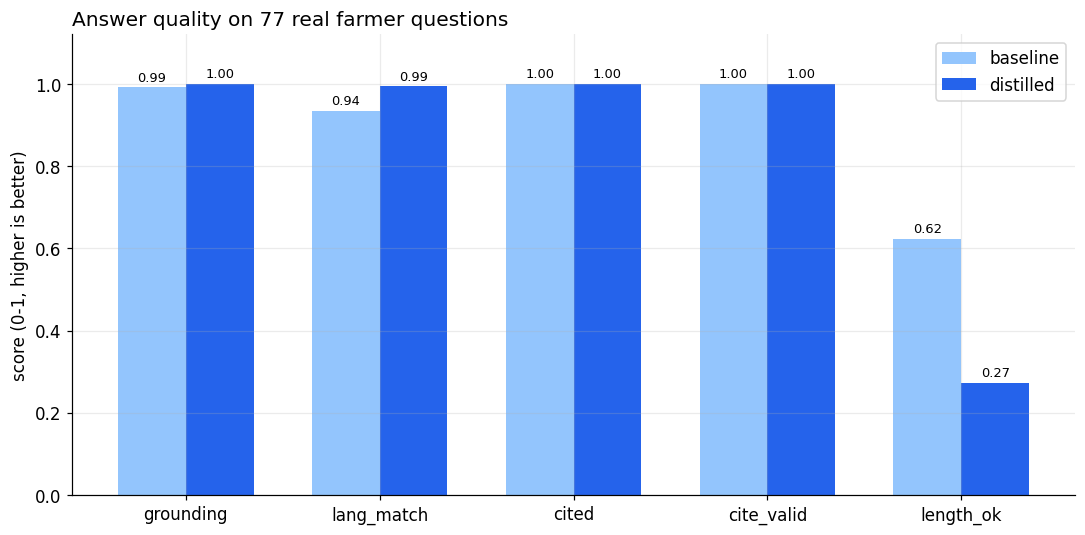

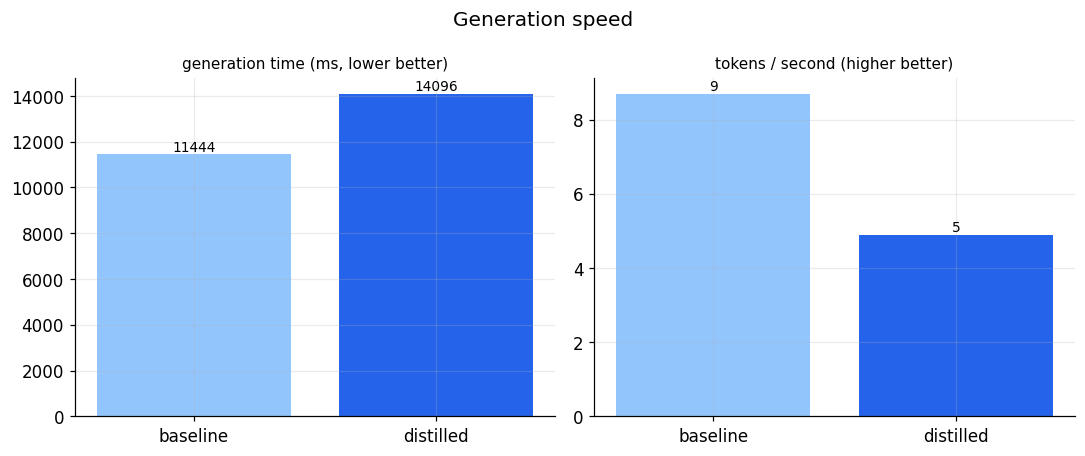

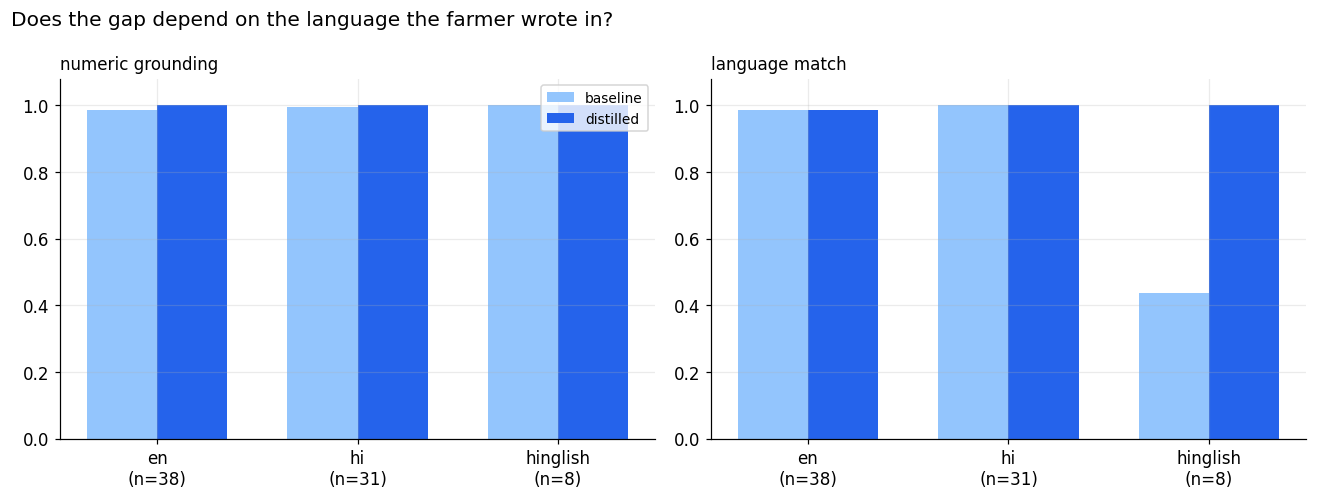

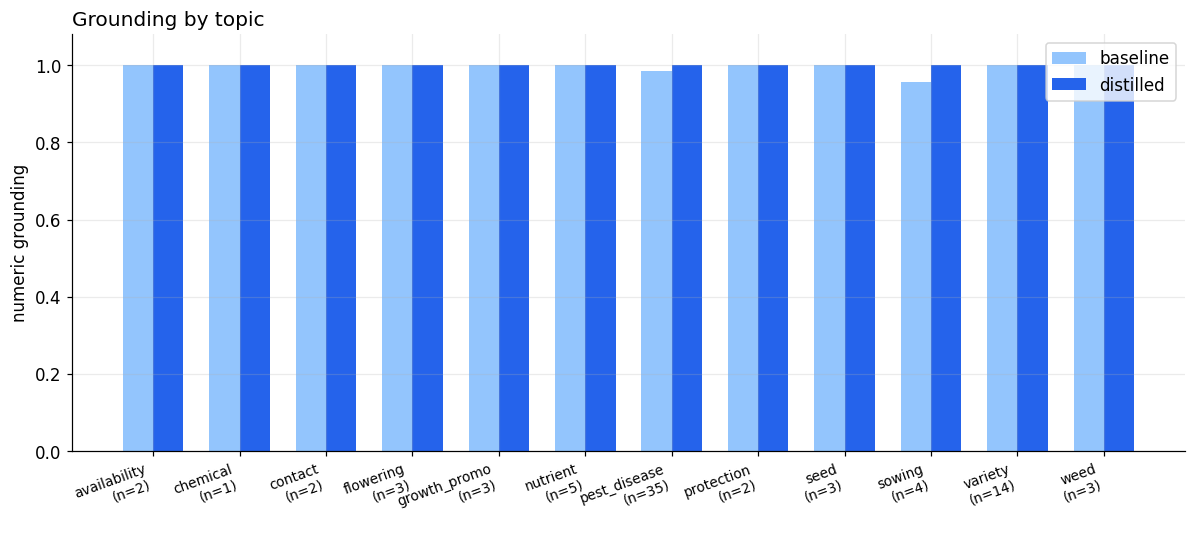

4 figures saved to /content/figures


In [44]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
COLORS = {"baseline": "#93c5fd", "distilled": "#2563eb"}
FIGS = []

def _save(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p, dpi=150, bbox_inches="tight")
    FIGS.append(p)

if not COMPARISON_TABLE.empty:
    # --- 1. quality metrics -------------------------------------------------------------------
    metrics = [m for m in ("grounding", "lang_match", "cited", "cite_valid", "length_ok")
               if m in COMPARISON_TABLE.columns]
    fig, ax = plt.subplots(figsize=(10, 5))
    x, width = np.arange(len(metrics)), 0.35
    for i, mn in enumerate(("baseline", "distilled")):
        vals = [COMPARISON_TABLE.loc[mn, m] if pd.notna(COMPARISON_TABLE.loc[mn, m]) else 0
                for m in metrics]
        bars = ax.bar(x + (i - 0.5) * width, vals, width, label=mn, color=COLORS[mn])
        ax.bar_label(bars, fmt="%.2f", fontsize=8.5, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.12); ax.set_ylabel("score (0-1, higher is better)")
    ax.set_title(f"Answer quality on {len(MAIN_SET)} real farmer questions", loc="left")
    ax.legend()
    fig.tight_layout(); _save(fig, "01_quality.png"); plt.show()

    # --- 2. speed ------------------------------------------------------------------------------
    if "gen_ms" in COMPARISON_TABLE.columns:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
        for ax, metric, title in zip(axes, ["gen_ms", "tok_s"],
                                     ["generation time (ms, lower better)",
                                      "tokens / second (higher better)"]):
            vals = [COMPARISON_TABLE.loc[m, metric] for m in ("baseline", "distilled")]
            b = ax.bar(["baseline", "distilled"], vals,
                       color=[COLORS["baseline"], COLORS["distilled"]])
            ax.bar_label(b, fmt="%.0f", fontsize=9)
            ax.set_title(title, fontsize=10)
        fig.suptitle("Generation speed")
        fig.tight_layout(); _save(fig, "02_speed.png"); plt.show()

    # --- 3. by language -------------------------------------------------------------------------
    if not LANG_TABLE.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
        for ax, suffix, title in zip(axes, ["_ground", "_lang"],
                                     ["numeric grounding", "language match"]):
            x = np.arange(len(LANG_TABLE))
            for i, mn in enumerate(("baseline", "distilled")):
                col = f"{mn}{suffix}"
                if col not in LANG_TABLE.columns:
                    continue
                ax.bar(x + (i - 0.5) * 0.35, LANG_TABLE[col].fillna(0), 0.35,
                       label=mn, color=COLORS[mn])
            ax.set_xticks(x)
            ax.set_xticklabels([f"{i}\n(n={n})" for i, n in zip(LANG_TABLE.index,
                                                                LANG_TABLE["n"])])
            ax.set_ylim(0, 1.08); ax.set_title(title, loc="left", fontsize=11)
        axes[0].legend(fontsize=9)
        fig.suptitle("Does the gap depend on the language the farmer wrote in?", x=0.005,
                     ha="left")
        fig.tight_layout(); _save(fig, "03_by_language.png"); plt.show()

    # --- 4. by topic ------------------------------------------------------------------------------
    if not GROUP_TABLE.empty:
        fig, ax = plt.subplots(figsize=(11, 5))
        x = np.arange(len(GROUP_TABLE))
        ax.bar(x - 0.175, GROUP_TABLE["baseline"].fillna(0), 0.35, label="baseline",
               color=COLORS["baseline"])
        ax.bar(x + 0.175, GROUP_TABLE["distilled"].fillna(0), 0.35, label="distilled",
               color=COLORS["distilled"])
        ax.set_xticks(x)
        ax.set_xticklabels([f"{i}\n(n={n})" for i, n in zip(GROUP_TABLE.index,
                                                            GROUP_TABLE["n"])],
                           rotation=20, ha="right", fontsize=9)
        ax.set_ylim(0, 1.08); ax.set_ylabel("numeric grounding")
        ax.set_title("Grounding by topic", loc="left")
        ax.legend()
        fig.tight_layout(); _save(fig, "04_by_topic.png"); plt.show()

    print(f"{len(FIGS)} figures saved to {FIG_DIR}")
else:
    print("[SKIP] no comparison table")

## 18. Health checks

Pass/fail gates, run once per model. A check that always passes tells you nothing, so **G1 now
reports `NOT EXERCISED`** rather than a free pass when no off-domain question is in the set.

In [45]:
def run_health_checks(model_name, rows):
    checks = []
    def hchk(label, ok, detail=""):
        checks.append((label, "PASS" if ok is True else "FAIL" if ok is False
                       else "NOT EXERCISED", detail))

    m_rows = [r for r in rows if r["model"] == model_name]
    gen = [r for r in m_rows if r.get("generated")]

    offdomain = [r for r in m_rows if r["group"] == "offdomain"]
    hchk("G1 off-topic never reaches the model",
         all(not r["generated"] for r in offdomain) if offdomain else None,
         f"{sum(bool(r['generated']) for r in offdomain)}/{len(offdomain)} generated"
         if offdomain else "no off-domain question in the set")

    bad = [r for r in gen if r["scores"]["numeric_grounding"] < 1.0]
    hchk("G2 every number traces to the source text", not bad,
         f"{len(bad)}/{len(gen)} answers contain a number not in the context")

    nonen = [r for r in gen if r["lang"] in ("hi", "hinglish")]
    hchk("G3 Hindi/Hinglish question -> same language answer",
         all(r["scores"]["language_match"] == 1.0 for r in nonen) if nonen else None,
         f"{sum(1 for r in nonen if r['scores']['language_match'] != 1.0)}/{len(nonen)} "
         "mismatched")

    fb = [r for r in gen if r["tier"] == "fallback_with_disclaimer"]
    hchk("G4 fallback answers carry the KVK line",
         all(KVK_DISCLAIMER[r["lang"]] in (r["answer"] or "") for r in fb) if fb else None,
         f"{len(fb)} fallback-tier answers")

    hchk("G5 answered questions cite their sources",
         sum(bool(r["scores"]["has_citation"]) for r in gen) >= 0.7 * max(len(gen), 1),
         f"{sum(bool(r['scores']['has_citation']) for r in gen)}/{len(gen)} cited")

    cv = [r for r in gen if r["scores"]["citation_valid"] is not None]
    hchk("G6 cited context numbers actually exist",
         all(r["scores"]["citation_valid"] == 1.0 for r in cv) if cv else None,
         f"{sum(1 for r in cv if r['scores']['citation_valid'] != 1.0)}/{len(cv)} "
         "cite a context that was never shown")
    return checks

HEALTH = {}
if RUN_HEALTH and ALL_ROWS:
    for model_name in ("baseline", "distilled"):
        HEALTH[model_name] = run_health_checks(model_name, ALL_ROWS)
        print(f"\n{model_name.upper()}")
        print("-" * 72)
        for lab, st, det in HEALTH[model_name]:
            print(f"  [{st:^13}] {lab:<44} {det}")
else:
    print("[SKIP] RUN_HEALTH = False or no rows")


BASELINE
------------------------------------------------------------------------
  [    PASS     ] G1 off-topic never reaches the model         0/2 generated
  [    FAIL     ] G2 every number traces to the source text    3/77 answers contain a number not in the context
  [    FAIL     ] G3 Hindi/Hinglish question -> same language answer 7/39 mismatched
  [    PASS     ] G4 fallback answers carry the KVK line       4 fallback-tier answers
  [    PASS     ] G5 answered questions cite their sources     77/77 cited
  [    PASS     ] G6 cited context numbers actually exist      0/77 cite a context that was never shown

DISTILLED
------------------------------------------------------------------------
  [    PASS     ] G1 off-topic never reaches the model         0/2 generated
  [    PASS     ] G2 every number traces to the source text    0/77 answers contain a number not in the context
  [    PASS     ] G3 Hindi/Hinglish question -> same language answer 0/39 mismatched
  [    PASS     ] G

## 19. Blind human check

Automated scores can be fooled: an answer can cite correctly and still miss the point. A blind
CSV is written — the two answers appear as "Answer A" and "Answer B" in a random order per
question, so you cannot favour the distilled one just because you know which it is. Fill in the
`which_is_better` column and rerun the cell to see the tally.

In [46]:
import random

HUMAN_SAMPLE_N = 10
random.seed(42)

HUMAN_PAIRS = []
if ALL_ROWS:
    _by = {m: {r["query"]: r for r in MAIN_ROWS if r["model"] == m}
           for m in ("baseline", "distilled")}
    _answerable = sorted(q for q in _by["baseline"]
                         if _by["baseline"][q].get("generated")
                         and _by["distilled"].get(q, {}).get("generated"))
    for q in random.sample(_answerable, min(HUMAN_SAMPLE_N, len(_answerable))):
        labels = ["baseline", "distilled"]
        random.shuffle(labels)
        texts = {"baseline": _by["baseline"][q]["answer"],
                 "distilled": _by["distilled"][q]["answer"]}
        HUMAN_PAIRS.append({"query": q, "A_model": labels[0], "B_model": labels[1],
                            "A_answer": texts[labels[0]], "B_answer": texts[labels[1]]})

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    _blind_path = os.path.join(OUTPUT_DIR, "human_eval_blind.csv")
    pd.DataFrame([{"query": p["query"], "answer_A": p["A_answer"], "answer_B": p["B_answer"],
                   "which_is_better": ""} for p in HUMAN_PAIRS]).to_csv(_blind_path, index=False)
    print(f"blind rating sheet ({len(HUMAN_PAIRS)} questions) -> {_blind_path}")
    print("Fill in which_is_better with A, B or T, then rerun this cell.")

HUMAN_RESULTS = []
if HUMAN_PAIRS and os.path.exists(os.path.join(OUTPUT_DIR, "human_eval_blind.csv")):
    _f = pd.read_csv(os.path.join(OUTPUT_DIR, "human_eval_blind.csv"))
    _rated = _f[_f["which_is_better"].astype(str).str.upper().isin(["A", "B", "T"])]
    _by_q = {p["query"]: p for p in HUMAN_PAIRS}
    for _, r in _rated.iterrows():
        p = _by_q.get(r["query"])
        if p:
            pref = str(r["which_is_better"]).upper()
            winner = "tie" if pref == "T" else p[f"{pref}_model"]
            HUMAN_RESULTS.append({"query": p["query"], "preference": pref, "winner": winner})

if HUMAN_RESULTS:
    HUMAN_SUMMARY_DF = pd.DataFrame(HUMAN_RESULTS)
    print("\n--- human preference (revealed) ---")
    print(HUMAN_SUMMARY_DF["winner"].value_counts().to_string())
    print(f"\n{len(HUMAN_RESULTS)} ratings. Fewer than ~20 shows a direction, not a result.")
else:
    HUMAN_SUMMARY_DF = pd.DataFrame()
    print("\n(no ratings filled in yet)")

blind rating sheet (10 questions) -> /content/drive/MyDrive/rag_comparison_baseline_vs_distilled/human_eval_blind.csv
Fill in which_is_better with A, B or T, then rerun this cell.

(no ratings filled in yet)


## 20. RAGAS — faithfulness

Everything above scores answers with hand-written rules. This section adds an independent second
opinion: **RAGAS faithfulness**, where another LLM reads each answer, breaks it into individual
claims, and checks whether each claim can be inferred from the retrieved context.

It is the same idea as `numeric_grounding`, but it reads whole sentences rather than digits — so
it catches a fabricated recommendation that happens to contain no numbers, which is exactly the
blind spot of the regex check. Showing the two side by side is the point: **where they disagree
is where you should go and read the answer yourself.**

### What was removed

The previous version of this section had fifteen cells that re-filtered, re-merged and re-exported
the same scores four different ways — a `df.head()` on an undefined variable, a Colab-only
`files.download()`, three separate "clean query" lists that disagreed with each other, and two
different filtered summaries. All of it is gone. What is left is: build the input, run the judge,
show the results, save them.

### Why answer relevancy is behind a flag

`answer_relevancy` works by generating candidate questions from the answer and embedding them, so
it needs a working embeddings endpoint. The aipipe proxy does not always serve one, and when it
fails the whole `evaluate()` call returns NaN for *both* metrics. `RUN_ANSWER_RELEVANCY` is off by
default; turn it on only after the embeddings smoke test in the next cell passes.

### Two things that make this measurement trustworthy

**The judge sees exactly what the model saw.** Contexts come from `row["context_texts"]`, stored
at generation time. The old code re-ran the search to reconstruct them, which could return
something slightly different and silently score the answer against text the model never read.

**Failures are visible.** `raise_exceptions=False` means a rate-limited call yields NaN instead of
killing the run, so the count of NaN is reported explicitly rather than being quietly averaged
away by `nanmean`.

In [21]:
!pip install -q "ragas>=0.2" langchain-openai datasets --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.9/353.9 kB 31.0 MB/s eta 0:00:00


### Connect to the judge

The token is read from Colab secrets and never hardcoded. Both smoke tests run before RAGAS
spends a few minutes and many calls.

In [47]:
RUN_ANSWER_RELEVANCY = False   # turn on only if the embeddings test below passes

import os
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage

if "AIPIPE_TOKEN" not in os.environ:
    try:
        from google.colab import userdata
        _t = userdata.get("AIPIPE_TOKEN")
        if _t:
            os.environ["AIPIPE_TOKEN"] = _t
            print("AIPIPE_TOKEN loaded from Colab secrets")
    except Exception:
        pass
if "AIPIPE_TOKEN" not in os.environ:
    raise RuntimeError(
        "No AIPIPE_TOKEN found. Add it as a Colab secret (key icon in the left sidebar, "
        "toggle notebook access on), or set os.environ['AIPIPE_TOKEN'] before running this "
        "cell. The token is intentionally never hardcoded here.")

AIPIPE_BASE_URL   = "https://aipipe.org/openai/v1"
RAGAS_JUDGE_MODEL = "gpt-4o"
RAGAS_EMBED_MODEL = "text-embedding-3-small"

judge_llm = ChatOpenAI(model=RAGAS_JUDGE_MODEL, api_key=os.environ["AIPIPE_TOKEN"],
                       base_url=AIPIPE_BASE_URL, temperature=0)

_test = judge_llm.invoke([HumanMessage(content="Reply with exactly: ok")])
print("chat connection test:", _test.content)

# The judge has to read Hindi and Hinglish answers, so check that too rather than assuming.
_hi = judge_llm.invoke([HumanMessage(
    content="Answer with one word, yes or no: does this sentence mention a fertiliser? "
            "'गेहूं में यूरिया 50 किलो प्रति एकड़ डालें'")])
print("hindi comprehension test:", _hi.content.strip())

judge_embeddings = None
if RUN_ANSWER_RELEVANCY:
    judge_embeddings = OpenAIEmbeddings(model=RAGAS_EMBED_MODEL,
                                        api_key=os.environ["AIPIPE_TOKEN"],
                                        base_url=AIPIPE_BASE_URL)
    try:
        _e = judge_embeddings.embed_query("test")
        print(f"embeddings connection test: vector length {len(_e)}")
    except Exception as e:
        print(f"[WARN] embeddings failed via aipipe: {type(e).__name__}: {str(e)[:160]}")
        print("       Setting RUN_ANSWER_RELEVANCY = False. Faithfulness does not need "
              "embeddings\n       and will still run.")
        RUN_ANSWER_RELEVANCY = False
        judge_embeddings = None
else:
    print("answer_relevancy is off -- faithfulness only (it needs no embeddings endpoint)")

chat connection test: ok
hindi comprehension test: Yes
answer_relevancy is off -- faithfulness only (it needs no embeddings endpoint)


### Build the judge's input

One row per generated answer: the question, the answer, and the exact context chunks the model
was shown. Refused questions are excluded — there is no context to check faithfulness against
when the system correctly said "I don't know", and including them would score an honest refusal
as an unfaithful answer.

In [48]:
RAGAS_INPUT = {}
if ALL_ROWS:
    for model_name in ("baseline", "distilled"):
        kept = []
        for r in MAIN_ROWS:                       # controls excluded: they were never answered
            if r["model"] != model_name or not r.get("generated"):
                continue
            ctxs = [c for c in (r.get("context_texts") or []) if c and c.strip()]
            if not ctxs or not (r.get("answer") or "").strip():
                continue
            kept.append({
                "user_input": r["query"],
                "response": r["answer"],
                "retrieved_contexts": ctxs,
            })
        RAGAS_INPUT[model_name] = kept
        print(f"{model_name:<10} {len(kept)} answers ready for the judge "
              f"(avg {np.mean([len(k['retrieved_contexts']) for k in kept]):.1f} contexts each)"
              if kept else f"{model_name:<10} nothing to score")

    _qb = {k["user_input"] for k in RAGAS_INPUT.get("baseline", [])}
    _qd = {k["user_input"] for k in RAGAS_INPUT.get("distilled", [])}
    if _qb != _qd:
        print(f"\n[NOTE] the two models answered different question sets "
              f"({len(_qb)} vs {len(_qd)}).\n       Only the {len(_qb & _qd)} questions both "
              "answered are compared like for like below.")
    RAGAS_SHARED_Q = _qb & _qd
else:
    RAGAS_SHARED_Q = set()
    print("[SKIP] no rows -- run section 15 first")

baseline   77 answers ready for the judge (avg 5.0 contexts each)
distilled  77 answers ready for the judge (avg 5.0 contexts each)


### Run the judge

One `evaluate()` call per model. Roughly 20 answers each, a few judge calls per answer — a couple
of minutes of API latency, no GPU.

The cell handles both the modern RAGAS API (`EvaluationDataset` + metric instances) and the older
one (HuggingFace `Dataset` + module-level metric objects), because which one you get depends on
the version pip resolves.

In [49]:
RAGAS_PER_ROW, RAGAS_ERRORS = {}, {}

if RUN_RAGAS and RAGAS_INPUT and any(RAGAS_INPUT.values()):
    from ragas import evaluate
    from ragas.llms import LangchainLLMWrapper
    try:
        from ragas.run_config import RunConfig
    except ImportError:
        RunConfig = None

    ragas_llm = LangchainLLMWrapper(judge_llm)
    ragas_emb = None
    if RUN_ANSWER_RELEVANCY and judge_embeddings is not None:
        from ragas.embeddings import LangchainEmbeddingsWrapper
        ragas_emb = LangchainEmbeddingsWrapper(judge_embeddings)

    # Modern API first, old API as fallback -- which one exists depends on the resolved version.
    _NEW_API = True
    try:
        from ragas import EvaluationDataset
        from ragas.metrics import Faithfulness
        METRICS = [Faithfulness(llm=ragas_llm)]
        if ragas_emb is not None:
            from ragas.metrics import ResponseRelevancy
            METRICS.append(ResponseRelevancy(llm=ragas_llm, embeddings=ragas_emb))
    except ImportError:
        _NEW_API = False
        from datasets import Dataset
        from ragas.metrics import faithfulness
        METRICS = [faithfulness]
        if ragas_emb is not None:
            from ragas.metrics import answer_relevancy
            METRICS.append(answer_relevancy)
    print(f"RAGAS {'0.2+' if _NEW_API else 'legacy'} API, metrics: "
          f"{[getattr(m, 'name', str(m)) for m in METRICS]}\n")

    _run_cfg = RunConfig(timeout=240, max_retries=6, max_workers=4) if RunConfig else None

    for model_name, rows in RAGAS_INPUT.items():
        if not rows:
            continue
        print(f"scoring {model_name} ({len(rows)} answers) ...")
        t0 = time.time()
        try:
            if _NEW_API:
                ds = EvaluationDataset.from_list(rows)
                kw = dict(dataset=ds, metrics=METRICS, llm=ragas_llm, raise_exceptions=False)
            else:
                ds = Dataset.from_list([{"question": r["user_input"], "answer": r["response"],
                                         "contexts": r["retrieved_contexts"]} for r in rows])
                kw = dict(dataset=ds, metrics=METRICS, llm=ragas_llm, raise_exceptions=False)
            if ragas_emb is not None:
                kw["embeddings"] = ragas_emb
            if _run_cfg is not None:
                kw["run_config"] = _run_cfg
            result = evaluate(**kw)
            df = result.to_pandas()
            # Column names differ across versions; normalise to what the rest of the cell uses.
            df = df.rename(columns={"question": "user_input", "answer": "response",
                                    "contexts": "retrieved_contexts"})
            RAGAS_PER_ROW[model_name] = df
            n_nan = int(df["faithfulness"].isna().sum()) if "faithfulness" in df else len(df)
            print(f"   done in {(time.time()-t0)/60:.1f} min   "
                  f"scored {len(df)-n_nan}/{len(df)}"
                  + (f"   [{n_nan} returned NaN -- judge call failed or was rate limited]"
                     if n_nan else ""))
        except Exception as e:
            RAGAS_ERRORS[model_name] = f"{type(e).__name__}: {str(e)[:300]}"
            print(f"   [FAILED] {RAGAS_ERRORS[model_name]}")
            e.__traceback__ = None
else:
    print("[SKIP] RUN_RAGAS = False, or nothing to score")

RAGAS 0.2+ API, metrics: ['faithfulness']

scoring baseline (77 answers) ...


/tmp/ipykernel_2350/2833817346.py:11: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(judge_llm)
/tmp/ipykernel_2350/2833817346.py:21: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness


Evaluating:   0%|          | 0/77 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[11]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor:Exception raised in Job[14]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor:Exception raised in Job[13]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor:Exception raised in Job[12]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor:Exception raised in Job[16]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor:Exception raised in Job[17]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor:Exception raised in Job[18]: RateLimitError(Error code: 429 - {'message': 'Usage $1.0128319399999983 / $1 in 7 days'})
ERROR:ragas.executor

In [50]:
# =============================================================================================
# Refusals are not unfaithful answers
# =============================================================================================
# RAGAS faithfulness = supported statements / total statements. "I do not have that information"
# is a claim about the MODEL'S OWN KNOWLEDGE STATE, which can never be inferred from retrieved
# context, so a correct refusal scores 0.00 by construction. Leaving those rows in the mean
# punishes the model for the exact behaviour the safety design asks for.
#
# So: faithfulness is reported on ATTEMPTED answers, and refusal rate is reported separately.
# A refusal is not a failure -- it is a different outcome and belongs in its own column.

REFUSAL_RE = re.compile(
    r"(?i)(?:"
    r"i (?:do not|don'?t) have|no information|not available in the (?:context|provided)|"
    r"cannot answer|can'?t answer|outside .{0,25}knowledge base|"
    r"jaankari nahi|jankari nahi|pata nahi|mujhe .{0,25}nahi|"
    r"जानकारी नहीं|जानकारी उपलब्ध नहीं|उपलब्ध नहीं|मेरे पास .{0,25}नहीं|पता नहीं"
    r")")

def is_refusal(answer_text, max_words=50):
    """A short answer whose substance is 'I don't know'.

    The length cap matters: a long, real answer that happens to say one figure is not available
    is NOT a refusal, and should still be judged on the claims it does make."""
    if not answer_text:
        return False
    body = SOURCES_LINE_RE.sub(" ", answer_text)
    for d in KVK_DISCLAIMER.values():          # the fallback disclaimer is boilerplate, not content
        body = body.replace(d, " ")
    return bool(REFUSAL_RE.search(body)) and len(body.split()) <= max_words


# Roughly how many statements the judge extracted. faithfulness is a ratio of small integers, so
# 0.333 -> 3 statements, 0.857 -> 7. Approximate, but it shows how coarse each score is: with 3
# statements the only possible values are 0, 0.33, 0.67, 1.0 and one judge misfire moves the
# score by a third.
def approx_statements(score, max_den=12):
    if score is None or (isinstance(score, float) and np.isnan(score)):
        return None
    if score in (0.0, 1.0):
        return None                            # any denominator fits; tells us nothing
    best, err = None, 1.0
    for d in range(2, max_den + 1):
        e = abs(score * d - round(score * d))
        if e < err - 1e-9:
            best, err = d, e
    return best if err < 0.02 else None


_ans = {(r["model"], r["query"]): r for r in MAIN_ROWS}

FAITH = RAGAS_PER_Q.copy()
FAITH["answer"]    = FAITH.apply(lambda r: (_ans.get((r["model"], r["query"])) or {}).get("answer"), axis=1)
FAITH["tier"]      = FAITH.apply(lambda r: (_ans.get((r["model"], r["query"])) or {}).get("tier"), axis=1)
FAITH["refused"]   = FAITH["answer"].map(is_refusal)
FAITH["n_stmts"]   = FAITH["faithfulness"].map(approx_statements)
FAITH["n_words"]   = FAITH["answer"].map(lambda a: len((a or "").split()))

ATTEMPTED = FAITH[~FAITH["refused"]].copy()

print("=" * 82)
print("FAITHFULNESS, REFUSALS SEPARATED")
print("=" * 82)

summary = pd.DataFrame({
    "faithfulness_all":       FAITH.groupby("model")["faithfulness"].mean(),
    "faithfulness_attempted": ATTEMPTED.groupby("model")["faithfulness"].mean(),
    "n_attempted":            ATTEMPTED.groupby("model")["faithfulness"].count(),
    "n_refused":              FAITH.groupby("model")["refused"].sum(),
    "refusal_rate":           FAITH.groupby("model")["refused"].mean(),
    "median_stmts":           FAITH.groupby("model")["n_stmts"].median(),
    "median_words":           FAITH.groupby("model")["n_words"].median(),
}).round(3)
print(summary.to_string())

_all  = summary["faithfulness_all"]
_att  = summary["faithfulness_attempted"]
print(f"\nincluding refusals : baseline {_all.get('baseline'):.3f}  "
      f"distilled {_all.get('distilled'):.3f}  "
      f"(delta {_all.get('distilled') - _all.get('baseline'):+.3f})")
print(f"attempted only     : baseline {_att.get('baseline'):.3f}  "
      f"distilled {_att.get('distilled'):.3f}  "
      f"(delta {_att.get('distilled') - _att.get('baseline'):+.3f})")

# Strictest like-for-like: only questions BOTH models attempted.
_ref_q = set(FAITH[FAITH["refused"]]["query"])
BOTH = FAITH[~FAITH["query"].isin(_ref_q)]
_b = BOTH.groupby("model")["faithfulness"].agg(["mean", "count"]).round(3)
print(f"\nquestions both models attempted (n={_b['count'].iloc[0]}):")
print(_b.to_string())

print("\n--- what was refused ---")
for _, r in FAITH[FAITH["refused"]].iterrows():
    print(f"   [{r['model']:<9}] tier={r['tier']:<24} {r['query'][:48]}")
    print(f"                {str(r['answer'])[:100]}")
if FAITH["refused"].sum() == 0:
    print("   nothing matched the refusal pattern -- check REFUSAL_RE against your answers")

# The granularity problem, stated with numbers.
_obs = sorted(FAITH["faithfulness"].dropna().unique())
print(f"\n{len(_obs)} distinct faithfulness values across {len(FAITH)} answers: "
      f"{[round(v, 3) for v in _obs]}")
print("These are ratios of small integers (1/3, 1/2, 2/3, 4/5...). With a median of "
      f"~{FAITH['n_stmts'].median():.0f} statements per answer, one judge misfire moves a "
      "score by\nseveral tenths -- which is why the per-question table matters more than the "
      "mean here.")

# Numeric grounding is at ceiling and has nothing left to say.
if not COMPARISON_TABLE.empty:
    _ng = COMPARISON_TABLE["grounding"]
    if _ng.min() >= 0.98:
        print(f"\n[NOTE] numeric_grounding is at ceiling ({_ng.get('baseline'):.3f} / "
              f"{_ng.get('distilled'):.3f}).\n       Report it as 'neither model invented a "
              "figure' -- it cannot separate the two models.")

FAITHFULNESS, REFUSALS SEPARATED
           faithfulness_all  faithfulness_attempted  n_attempted  n_refused  refusal_rate  median_stmts  median_words
model                                                                                                                
baseline              0.725                   0.725           21          0          0.00           3.5          57.0
distilled             0.798                   0.956           17          4          0.19           2.0          32.0

including refusals : baseline 0.725  distilled 0.798  (delta +0.073)
attempted only     : baseline 0.725  distilled 0.956  (delta +0.231)

questions both models attempted (n=17):
            mean  count
model                  
baseline   0.849     17
distilled  0.956     17

--- what was refused ---
   [distilled] tier=fallback_with_disclaimer Mere kheera mein black aphid lagi hai aur leaves
                Mujhe is baare mein jaankari nahi hai.
Sources: [2], [5]

Kripya upyog se pehle apn

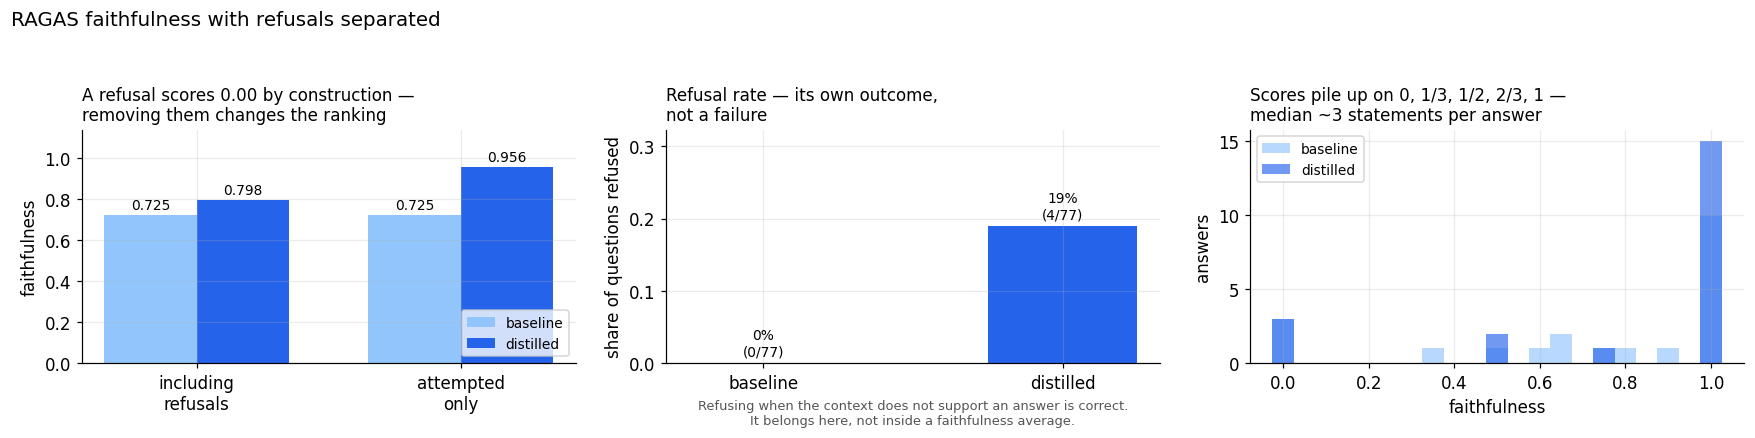

saved faithfulness_with_refusals.csv and 1 figure


In [51]:
# =============================================================================================
# Figures: refusals separated, granularity made visible
# =============================================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# ---- 1. the correction: all answers vs attempted only ----------------------------------------
ax = axes[0]
groups = ["including\nrefusals", "attempted\nonly"]
x, w = np.arange(len(groups)), 0.35
for i, mn in enumerate(("baseline", "distilled")):
    vals = [summary.loc[mn, "faithfulness_all"], summary.loc[mn, "faithfulness_attempted"]]
    b = ax.bar(x + (i - 0.5) * w, vals, w, label=mn, color=COLORS[mn])
    ax.bar_label(b, fmt="%.3f", fontsize=9, padding=2)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylim(0, 1.14); ax.set_ylabel("faithfulness")
ax.set_title("A refusal scores 0.00 by construction —\nremoving them changes the ranking",
             loc="left", fontsize=11)
ax.legend(fontsize=9, loc="lower right")

# ---- 2. refusal rate, reported on its own -----------------------------------------------------
ax = axes[1]
rates = [summary.loc[m, "refusal_rate"] for m in ("baseline", "distilled")]
b = ax.bar(["baseline", "distilled"], rates,
           color=[COLORS["baseline"], COLORS["distilled"]], width=0.5)
ax.bar_label(b, labels=[f"{r:.0%}\n({int(summary.loc[m,'n_refused'])}/{len(MAIN_SET)})"
                        for r, m in zip(rates, ("baseline", "distilled"))],
             fontsize=9, padding=3)
ax.set_ylim(0, max(max(rates) * 1.7, 0.14))
ax.set_ylabel("share of questions refused")
ax.set_title("Refusal rate — its own outcome,\nnot a failure", loc="left", fontsize=11)
ax.text(0.5, -0.26, "Refusing when the context does not support an answer is correct.\n"
                    "It belongs here, not inside a faithfulness average.",
        transform=ax.transAxes, ha="center", fontsize=8.5, color="#555")

# ---- 3. why the scores are so lumpy -------------------------------------------------------------
ax = axes[2]
for mn in ("baseline", "distilled"):
    v = FAITH[FAITH["model"] == mn]["faithfulness"].dropna()
    ax.hist(v, bins=np.linspace(-0.025, 1.025, 22), alpha=0.65, label=mn, color=COLORS[mn])
_med = FAITH["n_stmts"].median()
ax.set_xlabel("faithfulness"); ax.set_ylabel("answers")
ax.set_title(f"Scores pile up on 0, 1/3, 1/2, 2/3, 1 —\nmedian ~{_med:.0f} statements per answer"
             if pd.notna(_med) else "Scores pile up on 0, 1/3, 1/2, 2/3, 1",
             loc="left", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle("RAGAS faithfulness with refusals separated", x=0.005, ha="left", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 0.94])
_save(fig, "06_faithfulness_refusals.png")
plt.show()

FAITH.drop(columns=["answer"]).to_csv(
    os.path.join(OUTPUT_DIR, "faithfulness_with_refusals.csv"), index=False)
print(f"saved faithfulness_with_refusals.csv and 1 figure")

### Results

`numeric_grounding` (the regex check) is shown next to `faithfulness` (the LLM judge) on purpose.
They measure nearly the same thing two different ways, and **where they disagree is the
interesting part, not something to average away**:

- **high grounding, low faithfulness** → the numbers are right but a claim around them is not
  supported. The regex check cannot see this; it is the reason this section exists.
- **low grounding, high faithfulness** → usually a formatting artefact the judge forgave, e.g. a
  figure the model rewrote in different units. Worth reading before believing either score.

Per-question scores are printed for both models, sorted worst first, because with ~20 questions
the individual rows are more informative than the mean.

In [32]:
RAGAS_SUMMARY = pd.DataFrame()

if RAGAS_PER_ROW:
    _metric_cols = [c for c in ("faithfulness", "answer_relevancy", "response_relevancy")
                    if any(c in df.columns for df in RAGAS_PER_ROW.values())]

    rows = {}
    for model_name, df in RAGAS_PER_ROW.items():
        entry = {"n_scored": int(df["faithfulness"].notna().sum()) if "faithfulness" in df else 0,
                 "n_failed": int(df["faithfulness"].isna().sum()) if "faithfulness" in df else 0}
        for c in _metric_cols:
            if c in df.columns:
                entry[c] = round(float(np.nanmean(df[c].astype(float))), 3)
        rows[model_name] = entry
    RAGAS_SUMMARY = pd.DataFrame(rows).T
    RAGAS_SUMMARY.index.name = "model"

    print("RAGAS (LLM-judged, 0-1, higher is better)")
    print(RAGAS_SUMMARY.to_string())

    # ---- regex check vs LLM judge -------------------------------------------------------------
    if not COMPARISON_TABLE.empty and "faithfulness" in RAGAS_SUMMARY.columns:
        combined = (COMPARISON_TABLE[["grounding"]]
                    .join(RAGAS_SUMMARY[[c for c in _metric_cols
                                         if c in RAGAS_SUMMARY.columns]])
                    .rename(columns={"grounding": "numeric_grounding (regex)"}))
        print("\nregex check vs LLM judge:")
        print(combined.to_string())
        _d = combined["numeric_grounding (regex)"] - combined["faithfulness"]
        print(f"\ngap between the two methods: baseline {_d.get('baseline', float('nan')):+.3f}, "
              f"distilled {_d.get('distilled', float('nan')):+.3f}")
        print("a large positive gap means the regex check is being fooled by answers whose "
              "numbers\nare right but whose surrounding claims are not supported.")

    # ---- per question, both models side by side --------------------------------------------------
    per_q = []
    _ng = {(r["model"], r["query"]): r["scores"]["numeric_grounding"]
           for r in MAIN_ROWS if r.get("generated")}
    for model_name, df in RAGAS_PER_ROW.items():
        for _, r in df.iterrows():
            q = r["user_input"]
            per_q.append({"model": model_name, "query": q,
                          "faithfulness": r.get("faithfulness"),
                          "numeric_grounding": _ng.get((model_name, q)),
                          "lang": next((e["lang"] for e in MAIN_SET if e["q"] == q), None),
                          "group": next((e["group"] for e in MAIN_SET if e["q"] == q), None)})
    RAGAS_PER_Q = pd.DataFrame(per_q)

    print("\n--- per question, worst faithfulness first ---")
    _piv = RAGAS_PER_Q.pivot_table(index="query", columns="model", values="faithfulness")
    if {"baseline", "distilled"}.issubset(_piv.columns):
        _piv["delta"] = (_piv["distilled"] - _piv["baseline"]).round(3)
        _piv = _piv.sort_values("baseline")
    _piv.index = [q[:58] for q in _piv.index]
    print(_piv.round(3).to_string())

    if "delta" in _piv.columns:
        _better = int((_piv["delta"] > 0.05).sum())
        _worse  = int((_piv["delta"] < -0.05).sum())
        _same   = len(_piv) - _better - _worse
        print(f"\ndistilled better on {_better}, worse on {_worse}, "
              f"within +/-0.05 on {_same} of {len(_piv)} questions")

    print("\n--- lowest-faithfulness answers, worth reading yourself ---")
    for model_name, df in RAGAS_PER_ROW.items():
        if "faithfulness" not in df.columns:
            continue
        worst = df.dropna(subset=["faithfulness"]).nsmallest(2, "faithfulness")
        for _, r in worst.iterrows():
            print(f"\n[{model_name}] faithfulness={r['faithfulness']:.2f}")
            print(f"Q: {r['user_input']}")
            print(f"A: {str(r['response'])[:400]}")
elif RAGAS_ERRORS:
    print("RAGAS did not produce scores:")
    for k, v in RAGAS_ERRORS.items():
        print(f"   {k}: {v}")
else:
    print("[SKIP] no RAGAS results")

RAGAS (LLM-judged, 0-1, higher is better)
           n_scored  n_failed  faithfulness
model                                      
baseline       21.0       0.0         0.725
distilled      21.0       0.0         0.798

regex check vs LLM judge:
           numeric_grounding (regex)  faithfulness
model                                             
baseline                       0.993         0.725
distilled                      1.000         0.798

gap between the two methods: baseline +0.268, distilled +0.202
a large positive gap means the regex check is being fooled by answers whose numbers
are right but whose surrounding claims are not supported.

--- per question, worst faithfulness first ---
model                                                       baseline  distilled  delta
Ask about Anti-biotic and anti-fungal                          0.000       0.00  0.000
TELL ME PEST CONTROL IN PADDY?                                 0.000       0.00  0.000
wheat की फसल में पादप संरक्षण की जान

/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.tight_layout()
/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2350/2841633332.py:44: UserWarning: Glyph 2380 (\N{DEVANAGARI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  fig.tight_layout(

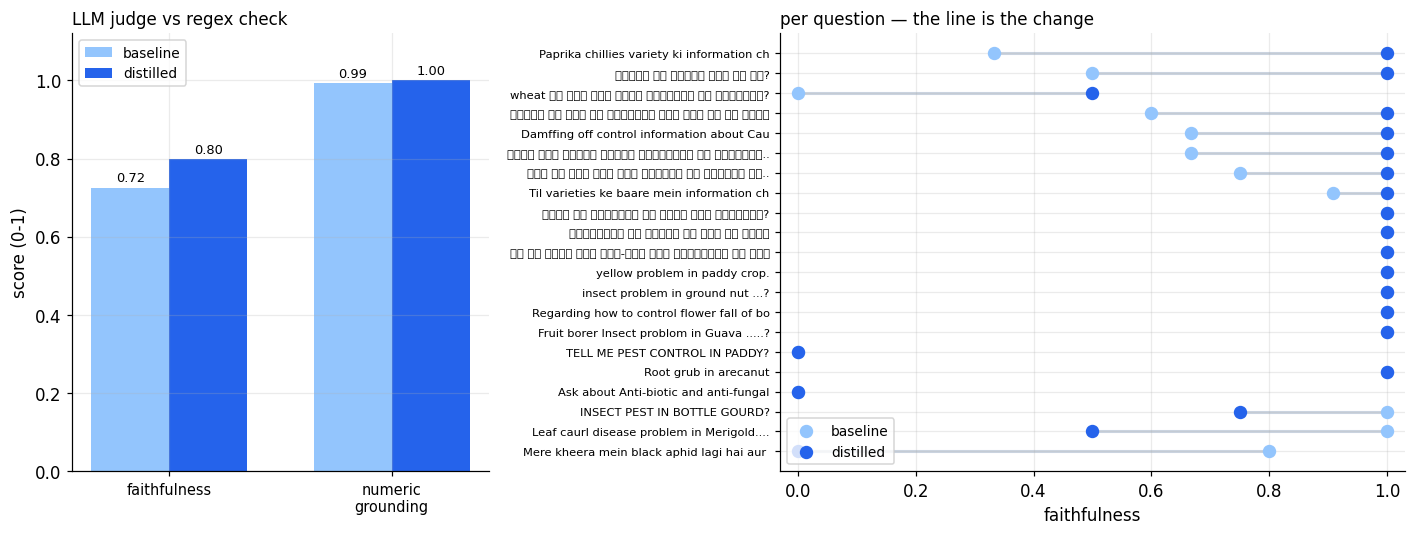

In [33]:
# ---- RAGAS chart -------------------------------------------------------------------------------
if not RAGAS_SUMMARY.empty and "faithfulness" in RAGAS_SUMMARY.columns:
    _cols = [c for c in ("faithfulness", "answer_relevancy", "response_relevancy")
             if c in RAGAS_SUMMARY.columns]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                             gridspec_kw={"width_ratios": [1, 1.5]})

    # left: judge vs regex, both models
    ax = axes[0]
    labels = _cols + (["numeric_grounding"] if not COMPARISON_TABLE.empty else [])
    x, width = np.arange(len(labels)), 0.35
    for i, mn in enumerate(("baseline", "distilled")):
        vals = []
        for lab in labels:
            if lab == "numeric_grounding":
                vals.append(float(COMPARISON_TABLE.loc[mn, "grounding"]))
            else:
                vals.append(float(RAGAS_SUMMARY.loc[mn, lab]))
        b = ax.bar(x + (i - 0.5) * width, vals, width, label=mn, color=COLORS[mn])
        ax.bar_label(b, fmt="%.2f", fontsize=8.5, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace("_", "\n") for l in labels], fontsize=9.5)
    ax.set_ylim(0, 1.12); ax.set_ylabel("score (0-1)")
    ax.set_title("LLM judge vs regex check", loc="left", fontsize=11)
    ax.legend(fontsize=9)

    # right: per question, paired
    ax2 = axes[1]
    if "delta" in _piv.columns:
        order = _piv.sort_values("delta")
        y = np.arange(len(order))
        ax2.hlines(y, order["baseline"], order["distilled"], color="#cbd5e1", lw=2, zorder=1)
        ax2.scatter(order["baseline"], y, s=60, color=COLORS["baseline"], zorder=2,
                    label="baseline")
        ax2.scatter(order["distilled"], y, s=60, color=COLORS["distilled"], zorder=2,
                    label="distilled")
        ax2.set_yticks(y)
        ax2.set_yticklabels([q[:42] for q in order.index], fontsize=7.5)
        ax2.set_xlim(-0.03, 1.03)
        ax2.set_xlabel("faithfulness")
        ax2.set_title("per question — the line is the change", loc="left", fontsize=11)
        ax2.legend(fontsize=9, loc="lower left")
    fig.tight_layout()
    _save(fig, "05_ragas.png")
    plt.show()
else:
    print("[SKIP] no RAGAS summary to chart")

## 21. Save everything

One folder with every generated answer, every table, every figure, and a manifest recording what
produced them.

In [27]:
import hashlib, shutil

if EXPORT_ARTIFACTS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    if ALL_ROWS:
        with open(os.path.join(OUTPUT_DIR, "all_generations.jsonl"), "w",
                  encoding="utf-8") as f:
            for r in ALL_ROWS:
                f.write(json.dumps({k: v for k, v in r.items() if not k.startswith("_")},
                                   ensure_ascii=False, default=str) + "\n")
        print(f"all_generations.jsonl          {len(ALL_ROWS)} rows")

    for _name, _df in (("comparison_table.csv", COMPARISON_TABLE),
                       ("by_language.csv", LANG_TABLE),
                       ("by_topic.csv", GROUP_TABLE),
                       ("ragas_summary.csv", RAGAS_SUMMARY),
                       ("human_eval_results.csv", HUMAN_SUMMARY_DF)):
        if isinstance(_df, pd.DataFrame) and not _df.empty:
            _df.to_csv(os.path.join(OUTPUT_DIR, _name))
            print(f"{_name:<30} saved")

    if "RAGAS_PER_Q" in dir() and isinstance(RAGAS_PER_Q, pd.DataFrame) and not RAGAS_PER_Q.empty:
        RAGAS_PER_Q.to_csv(os.path.join(OUTPUT_DIR, "ragas_per_question.csv"), index=False)
        print("ragas_per_question.csv         saved")

    # One flat sheet with everything per answer -- the file to open when writing the report.
    if ALL_ROWS:
        _faith = {}
        for mn, df in RAGAS_PER_ROW.items():
            for _, r in df.iterrows():
                _faith[(mn, r["user_input"])] = r.get("faithfulness")
        detail = []
        for r in MAIN_ROWS:
            s = r.get("scores", {})
            detail.append({
                "model": r["model"], "query": r["query"], "lang": r["lang"],
                "group": r["group"], "expect_crop": r["expect_crop"],
                "tier": r["tier"], "top_score": r["top_score"], "generated": r["generated"],
                "answer": r["answer"],
                "faithfulness": _faith.get((r["model"], r["query"])),
                "numeric_grounding": s.get("numeric_grounding"),
                "unsupported_numbers": ", ".join(s.get("unsupported_numbers") or []),
                "language_match": s.get("language_match"), "answer_lang": s.get("answer_lang"),
                "has_citation": s.get("has_citation"), "citation_valid": s.get("citation_valid"),
                "out_tokens": s.get("out_tokens"), "length_ok": s.get("length_ok"),
                "contexts": " ||| ".join(r.get("context_texts") or []),
            })
        pd.DataFrame(detail).to_csv(os.path.join(OUTPUT_DIR, "detailed_evaluation.csv"),
                                    index=False, encoding="utf-8-sig")
        print("detailed_evaluation.csv        saved (one row per answer, everything joined)")

    for _p in FIGS:
        shutil.copy(_p, os.path.join(OUTPUT_DIR, os.path.basename(_p)))
    print(f"figures                        {len(FIGS)} copied")

    run_manifest = {
        "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "notebook": "rag_baseline_vs_distilled",
        "baseline_model": BASELINE_MODEL_ID,
        "distilled_base_model": DISTILLED_BASE_MODEL_ID,
        "adapter_dir": ADAPTER_DIR,
        "training_manifest": TRAIN_MANIFEST,
        "generation_settings": GEN_BASELINE,
        "answer_len_range": list(ANSWER_LEN_RANGE),
        "query_normalisation": NORMALISE_QUERIES,
        "eval_questions": len(MAIN_SET),
        "offdomain_controls": len(EVAL_SET) - len(MAIN_SET),
        "eval_languages": {k: v for k, v in
                           __import__("collections").Counter(e["lang"] for e in MAIN_SET).items()},
        "collection": COLLECTION_NAME,
        "embed_model": EMBED_MODEL_NAME,
        "ragas_judge": RAGAS_JUDGE_MODEL if RAGAS_PER_ROW else None,
        "ragas_metrics": ["faithfulness"] + (["answer_relevancy"] if RUN_ANSWER_RELEVANCY else []),
        "ragas_errors": RAGAS_ERRORS,
        "human_ratings": len(HUMAN_RESULTS),
    }
    run_manifest["config_hash"] = hashlib.sha256(
        json.dumps(run_manifest, sort_keys=True, default=str).encode()).hexdigest()[:12]
    with open(os.path.join(OUTPUT_DIR, "run_manifest.json"), "w", encoding="utf-8") as f:
        json.dump(run_manifest, f, indent=2, ensure_ascii=False, default=str)

    print(f"\neverything saved to {OUTPUT_DIR}")
    print(f"config_hash: {run_manifest['config_hash']}")
else:
    print("[SKIP] EXPORT_ARTIFACTS = False")

all_generations.jsonl          46 rows
comparison_table.csv           saved
by_language.csv                saved
by_topic.csv                   saved
ragas_summary.csv              saved
ragas_per_question.csv         saved
detailed_evaluation.csv        saved (one row per answer, everything joined)
figures                        5 copied

everything saved to /content/drive/MyDrive/rag_comparison_baseline_vs_distilled
config_hash: 7efae569e141


## What this notebook shows, and what it does not

**What it shows.** Two models — one exactly as downloaded, one with the trained adapter attached —
answering 21 real KCC-style farmer questions through the same database, the same prompt and the
same safety gate, scored by five rule-based checks and by an independent LLM judge, with two
off-domain controls proving the gate still fires.

**What it does not show.**

- **21 questions is a direction, not a result.** With roughly 20 answered questions per model, a
  difference of a few hundredths in any mean is noise. Treat the per-question table in section 20
  as the primary evidence and the means as a summary of it.
- **`numeric_grounding` still has a blind spot.** The fixes remove four ways it was
  *under-scoring*, but it fundamentally cannot see a wrong claim with no numbers in it. That is
  what faithfulness is for, and why the two are printed side by side rather than averaged.
- **The judge is a language model too.** It can be wrong, inconsistent between runs, and mildly
  biased toward answers written in a style close to its own. It is a second opinion, not a
  verdict — the Hindi comprehension smoke test in section 20 checks it can read the answers at
  all, which is the minimum bar, not proof it judges them well.
- **Retrieval-side numbers should be near-identical between models.** `abstain_acc`, tier
  distribution and which corpus wins depend on retrieval, which does not change. If they differ
  noticeably, something is wrong with the setup rather than with either model.
- **Query normalisation changes what is retrieved.** Section 8 prints the before/after top score
  for the two messiest questions so the effect is measured rather than assumed. The generator
  always sees the farmer's original words, so this affects retrieval only — but it does mean these
  numbers are not directly comparable to a run with `NORMALISE_QUERIES = False`.
- **Questions the gate refused contribute no generation scores.** If several of the 21 fell below
  the threshold, the quality means rest on fewer answers than the header suggests. The count is
  printed at the end of section 15 — quote it.

In [ ]:
!pip install -q nltk rouge-score

In [ ]:
# =====================================================================
# 22. BLEU and ROUGE evaluation against KCC references (with Q&A matching)
# =====================================================================
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import pandas as pd
import numpy as np
import re
from difflib import SequenceMatcher

nltk.download('punkt', quiet=True)
from nltk.tokenize import word_tokenize

# ---- Helper: extract Question and Answer from a KCC chunk -----------
def extract_kcc_qa(chunk_text):
    """
    Extract (question, answer) from a KCC chunk.
    Returns (None, None) if either is missing.
    """
    if not chunk_text:
        return None, None
    # Patterns for question and answer
    q_patterns = [
        r'(?:Q|Question|प्रश्न)\s*[:.]\s*(.*?)(?=\n\s*(?:Ans|Answer|उत्तर)|$)',
        r'^([^.\n]+[?.!])\s*(?:Ans|Answer|उत्तर)',  # fallback
    ]
    a_patterns = [
        r'(?:Ans|Answer|उत्तर)\s*[:.]\s*(.*?)(?=\n\s*(?:Q|Question|प्रश्न)|$)',
    ]
    question = None
    answer = None
    for pat in q_patterns:
        m = re.search(pat, chunk_text, re.IGNORECASE | re.DOTALL)
        if m:
            question = m.group(1).strip()
            break
    for pat in a_patterns:
        m = re.search(pat, chunk_text, re.IGNORECASE | re.DOTALL)
        if m:
            answer = m.group(1).strip()
            break
    # If no explicit markers, try splitting by newlines (common in KCC logs)
    if not question or not answer:
        lines = [l.strip() for l in chunk_text.split('\n') if l.strip()]
        # Look for a line ending with ? as question, and the next non-empty as answer
        for i, line in enumerate(lines):
            if line.endswith('?'):
                question = line
                if i + 1 < len(lines):
                    answer = lines[i + 1]
                break
    return question, answer

# ---- Build reference set with matching ---------------------------------
print("Building matched KCC references...")
KCC_REFERENCES = {}  # query -> reference answer
KCC_MATCHED_COUNT = 0
KCC_MISSING = []

SIMILARITY_THRESHOLD = 0.85  # adjust if needed

# Clean function for matching (remove punctuation, lower, collapse spaces)
def clean_text_for_match(t):
    t = re.sub(r'[^a-zA-Z0-9\s\u0900-\u097F]', ' ', str(t))
    return re.sub(r'\s+', ' ', t).strip().lower()

for e in MAIN_SET:
    q = e["q"]
    # Retrieve top 5 chunks to find the best matching KCC
    search_res = search_agri_knowledge(q, top_k=5)
    best_match = None
    best_score = 0.0
    best_answer = None

    for hit in search_res["results"]:
        if hit["source_type"] != "kcc":
            continue
        kcc_q, kcc_a = extract_kcc_qa(hit["text"])
        if not kcc_q or not kcc_a:
            continue
        # Compute similarity between the user query and the KCC question
        clean_q = clean_text_for_match(q)
        clean_kcc_q = clean_text_for_match(kcc_q)
        # Use SequenceMatcher for fuzzy matching
        sim = SequenceMatcher(None, clean_q, clean_kcc_q).ratio()
        # Also require that the KCC question contains the main crop/pest words
        # (optional but helps avoid false positives)
        if sim > best_score:
            best_score = sim
            best_match = kcc_q
            best_answer = kcc_a

    if best_match and best_score >= SIMILARITY_THRESHOLD:
        KCC_REFERENCES[q] = best_answer
        KCC_MATCHED_COUNT += 1
        # Optional debug: print match quality
        # print(f"Matched: {q[:40]}... score={best_score:.3f}")
    else:
        KCC_MISSING.append((q, best_score))

print(f"Matched {KCC_MATCHED_COUNT} out of {len(MAIN_SET)} questions.")
if KCC_MISSING:
    print(f"No good match for {len(KCC_MISSING)} questions (e.g., {KCC_MISSING[0][0][:40]}...)")
    # Optionally, you can lower the threshold or log the scores.

# ---- Compute BLEU and ROUGE -----------------------------------------
def tokenize(text):
    return word_tokenize(text.lower())

def compute_bleu(reference, hypothesis):
    ref_tokens = tokenize(reference)
    hyp_tokens = tokenize(hypothesis)
    if not ref_tokens or not hyp_tokens:
        return 0.0
    smooth = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smooth)

def compute_rouge(reference, hypothesis):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    scores = scorer.score(reference, hypothesis)
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure,
    }

results = []
for q, ref in KCC_REFERENCES.items():
    baseline_row = next((r for r in MAIN_ROWS if r["model"] == "baseline" and r["query"] == q), None)
    distilled_row = next((r for r in MAIN_ROWS if r["model"] == "distilled" and r["query"] == q), None)
    if not baseline_row or not distilled_row:
        continue
    baseline_ans = baseline_row.get("answer")
    distilled_ans = distilled_row.get("answer")
    if not baseline_ans or not distilled_ans:
        continue
    # Compute scores
    bleu_b = compute_bleu(ref, baseline_ans)
    bleu_d = compute_bleu(ref, distilled_ans)
    rouge_b = compute_rouge(ref, baseline_ans)
    rouge_d = compute_rouge(ref, distilled_ans)
    results.append({
        'query': q,
        'matched_kcc_question': KCC_REFERENCES.get(q, ''),  # store for debugging
        'bleu_baseline': bleu_b,
        'bleu_distilled': bleu_d,
        'rouge1_baseline': rouge_b['rouge1'],
        'rouge1_distilled': rouge_d['rouge1'],
        'rouge2_baseline': rouge_b['rouge2'],
        'rouge2_distilled': rouge_d['rouge2'],
        'rougeL_baseline': rouge_b['rougeL'],
        'rougeL_distilled': rouge_d['rougeL'],
    })

if results:
    df_bleu_rouge = pd.DataFrame(results)
    # Summarise
    summary_cols = ['bleu_baseline', 'bleu_distilled',
                    'rouge1_baseline', 'rouge1_distilled',
                    'rouge2_baseline', 'rouge2_distilled',
                    'rougeL_baseline', 'rougeL_distilled']
    summary = df_bleu_rouge[summary_cols].mean().round(4)
    print("\n--- BLEU & ROUGE summary (mean over {} matched questions) ---".format(len(df_bleu_rouge)))
    print(summary.to_string())

    # Delta
    df_bleu_rouge['bleu_delta'] = df_bleu_rouge['bleu_distilled'] - df_bleu_rouge['bleu_baseline']
    df_bleu_rouge['rouge1_delta'] = df_bleu_rouge['rouge1_distilled'] - df_bleu_rouge['rouge1_baseline']
    print("\n--- Delta (Distilled - Baseline) ---")
    print("BLEU  mean delta: {:.4f}".format(df_bleu_rouge['bleu_delta'].mean()))
    print("ROUGE-1 mean delta: {:.4f}".format(df_bleu_rouge['rouge1_delta'].mean()))

    # Save
    df_bleu_rouge.to_csv(os.path.join(OUTPUT_DIR, "bleu_rouge_scores.csv"), index=False)
    print(f"\nSaved to {OUTPUT_DIR}/bleu_rouge_scores.csv")
else:
    print("No results computed. Try lowering the SIMILARITY_THRESHOLD.")